# Getting Started

## Importing Libraries
We begin by importing the **libraries** that will handle our complete **data processing, data analysis, and visual graphic representation.**

- First, we load the **NumPy** library as np, which provides highly efficient support for multi-dimensional arrays and advanced numerical operations.

- Next, we load the **Pandas** library as pd, which is the foundational tool we will use to structure, filter, clean, and merge our datasets into clean tables.

- Next, we load the main plotting module from **Matplotlib** as plt to generate basic geometric figures and chart figures.

- Finally, we load the **Seaborn** library as sns, which builds directly on top of Matplotlib to let us draw advanced statistical plots and clean data visualizations for our exploration phase.
(In some enviroments seaborn is not installed, in that case we can install seaborn by typing: %pip install seaborn and then import it.)

In [1]:
import numpy as np
import pandas as pd
%pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1.2 Importing main datasets

Now we import the **4 core datasets:** the supplier quote table, the tube technical features table, the bill of materials table, and the additional technical specifications table.

- We use the **read_csv** function from Pandas to load our **supplier training data.** We explicitly pass parse_dates at index 2 to transform the third column, which is the supplier quote date string, into a date-time format.

- Next, we load the tube attributes table to read the primary **engineering shapes, lengths, diameters, and geometries of each individual item.**

- After that, we load the **bill of materials** dataset to check the lists of parts and sub-component quantities assigned to each unique tube assembly.

- Finally, we load the special **specifications dataset** to keep track of manufacturing flags and secondary processing requirements.

In [2]:
train = pd.read_csv(r"C:\Users\nweke\Downloads\train_set.csv", parse_dates=[2])
tube = pd.read_csv(r"C:\Users\nweke\Downloads\tube.csv")
bom = pd.read_csv(r"C:\Users\nweke\Downloads\bill_of_materials.csv")
specs = pd.read_csv(r"C:\Users\nweke\Downloads\specs.csv")

# 2 Dataset exploration
This section shows our exploratory data analysis phase. 

Before performing any feature engineering, dataset merging, or predictive model training, we must check the sizes, record samples, structural data types, boundary ranges, and baseline distributions of our individual raw manufacturing tables to find any hidden errors.

## Dataset Train (Supplier Data)
First, we run **train.shape** to return the raw grid footprint of the supplier dataset. This tells us it contains exactly **30,213** quote rows and **8** variables.

In [3]:
train.shape

(30213, 8)

Next, **train.sample(3)** randomly retrieves **3** different rows from the table to give us a snapshot of what a typical record looks like.

In [4]:
train.sample(3)

,tube_assembly_id,supplier,quote_date,annual_usage,min_order_quantity,bracket_pricing,quantity,cost
7550,TA-04252,S-0066,2013-09-01,0,0,Yes,5,9.136282
10577,TA-06283,S-0066,2013-05-01,0,0,Yes,100,3.318996
10264,TA-06094,S-0066,2013-07-21,0,0,Yes,1,22.011651


Then, **train.columns** prints out a complete index of all **8 column headings,** confirming our variables include tracking IDs, supplier codes, dates, usage amounts, and total purchase costs.

In [5]:
train.columns

Index(['tube_assembly_id', 'supplier', 'quote_date', 'annual_usage',
       'min_order_quantity', 'bracket_pricing', 'quantity', 'cost'],
      dtype='object')

After that, **train.dtypes** lists the types for every attribute, verifying that texts are read as general objects, quantities are whole integers, cost is a floating decimal, and quote dates were successfully parsed into time-stamps.

In [6]:
train.dtypes

tube_assembly_id              object
supplier                      object
quote_date            datetime64[ns]
annual_usage                   int64
min_order_quantity             int64
bracket_pricing               object
quantity                       int64
cost                         float64
dtype: object

Next, **train.nlargest**(5, "annual_usage") isolates the **5** transactions with the highest yearly part demand to evaluate top volume behavior.

In [7]:
train.nlargest(5, "annual_usage")

,tube_assembly_id,supplier,quote_date,annual_usage,min_order_quantity,bracket_pricing,quantity,cost
26107,TA-19556,S-0072,2013-03-13,150000,1,Yes,1,0.653784
12579,TA-07644,S-0058,2012-03-15,106694,5,No,5,25.291699
9454,TA-05484,S-0026,2007-07-02,65000,1,No,1,1.296440
5623,TA-03160,S-0066,2009-01-02,64300,1,No,1,3.341253
12557,TA-07591,S-0058,2006-08-01,48689,1,No,1,4.737847


Similarly, **train.nsmallest**(5, "annual_usage") shows the **5** lowest annual demand, to see if zero-usage rows exist and how they behave.

In [8]:
train.nsmallest(5, "annual_usage")

,tube_assembly_id,supplier,quote_date,annual_usage,min_order_quantity,bracket_pricing,quantity,cost
0,TA-00002,S-0066,2013-07-07,0,0,Yes,1,21.905933
1,TA-00002,S-0066,2013-07-07,0,0,Yes,2,12.341214
2,TA-00002,S-0066,2013-07-07,0,0,Yes,5,6.601826
3,TA-00002,S-0066,2013-07-07,0,0,Yes,10,4.687770
4,TA-00002,S-0066,2013-07-07,0,0,Yes,25,3.541561


Then, **train.index** checks the structural row index of the table to verify it uses a sequential, step-by-step counter from record **0** up to **30,213.**

In [9]:
train.index

RangeIndex(start=0, stop=30213, step=1)

After that, **pd.concat** connects together the first 5 records and the final 5 records into a single display window to verify dataset layout continuity from top to bottom.

In [10]:
pd.concat([train.head(), train.tail()])

,tube_assembly_id,supplier,quote_date,annual_usage,min_order_quantity,bracket_pricing,quantity,cost
0,TA-00002,S-0066,2013-07-07,0,0,Yes,1,21.905933
1,TA-00002,S-0066,2013-07-07,0,0,Yes,2,12.341214
2,TA-00002,S-0066,2013-07-07,0,0,Yes,5,6.601826
3,TA-00002,S-0066,2013-07-07,0,0,Yes,10,4.687770
4,TA-00002,S-0066,2013-07-07,0,0,Yes,25,3.541561
30208,TA-21190,S-0041,2013-09-10,869,75,No,75,5.945260
30209,TA-21191,S-0041,2013-09-10,752,1,No,1,6.131658
30210,TA-21195,S-0041,2013-08-05,1,80,No,80,5.066130
30211,TA-21196,S-0062,2005-05-09,422,1,No,1,18.214141
30212,TA-21197,S-0026,2009-07-30,3,1,No,1,53.618624


Next, **train.info()** produces a summary of data integrity and system footprint, providing exact counts of non-null cells per column to confirm there are no missing data gaps across any of the records.

In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30213 entries, 0 to 30212
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   tube_assembly_id    30213 non-null  object        
 1   supplier            30213 non-null  object        
 2   quote_date          30213 non-null  datetime64[ns]
 3   annual_usage        30213 non-null  int64         
 4   min_order_quantity  30213 non-null  int64         
 5   bracket_pricing     30213 non-null  object        
 6   quantity            30213 non-null  int64         
 7   cost                30213 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(3)
memory usage: 1.8+ MB


**Train.describe()** automatically generates fundamental descriptive statistics, including mean values, standard deviations, minimums, maximums, for all our numerical features.

In [12]:
train.describe()

,quote_date,annual_usage,min_order_quantity,quantity,cost
count,30213,30213.000000,30213.000000,30213.000000,30213.000000
mean,2012-08-05 01:17:49.883824896,120.369377,2.084699,38.389369,13.433317
min,1982-09-22 00:00:00,0.000000,0.000000,1.000000,0.503553
25%,2012-10-25 00:00:00,0.000000,0.000000,2.000000,3.878190
50%,2013-07-01 00:00:00,0.000000,0.000000,10.000000,6.521146
75%,2013-09-01 00:00:00,2.000000,0.000000,40.000000,13.431781
max,2017-01-01 00:00:00,150000.000000,535.000000,2500.000000,1000.000000
std,NaN,1590.331872,12.742776,70.761392,28.663200


Finally, we create a graphing window using **matplotlib,** call the **seaborn** library to build a frequency histogram with a continuous probability density line overlaying our target cost variable, limit the horizontal scale zoom between **0 and 100 units** to clearly see the peak distribution, and render the chart on screen to show that item costs are highly skewed toward lower prices.

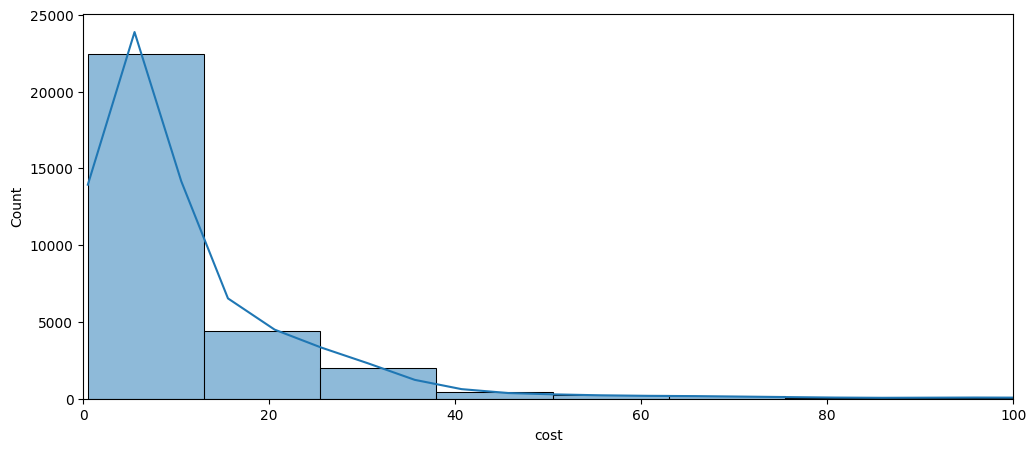

In [13]:

plt.figure(figsize=(12, 5))
sns.histplot(train['cost'], bins=80, kde=True)

plt.xlim(0, 100)   # zoom into 0–100
plt.show()

## Dataset Tube

Now we focus on the tube technical features dataset, we perform a sequence of structural checks to fully understand our technical tube dataset.

First, we execute **tube.shape** to determine the exact grid of our geometry table, which tells us it has **21,198** individual component records across **16** structural columns.

In [14]:
tube.shape

(21198, 16)

Next, we run **tube.sample(3),** to look at **3** real records from the dataset, allowing us to inspect entries like material IDs, wall measurements, or end-connection types.

In [15]:
tube.sample(3)

,tube_assembly_id,material_id,diameter,wall,length,num_bends,bend_radius,end_a_1x,end_a_2x,end_x_1x,end_x_2x,end_a,end_x,num_boss,num_bracket,other
7712,TA-07713,SP-0029,10.00,3.50,71.0,9,38.10,N,N,N,N,NONE,NONE,0,0,0
8028,TA-08029,SP-0039,6.35,0.71,220.0,5,19.05,N,N,N,N,EF-008,EF-008,0,0,0
6068,TA-06069,SP-0029,25.40,3.05,100.0,2,50.80,N,N,N,N,EF-003,EF-003,1,0,0


Then, **tube.columns** displays a list of all **16 variable names,** showing us that we track physical parameters like outer diameter, wall thickness, line length, bend radius, and component attachments like brackets.

In [16]:
tube.columns

Index(['tube_assembly_id', 'material_id', 'diameter', 'wall', 'length',
       'num_bends', 'bend_radius', 'end_a_1x', 'end_a_2x', 'end_x_1x',
       'end_x_2x', 'end_a', 'end_x', 'num_boss', 'num_bracket', 'other'],
      dtype='object')

After that, **tube.dtypes** inspects the storage data type of each attribute, ensuring dimensions are loaded as floating decimals, curve frequencies are stored as integers, and identification labels are registered as text objects.

In [17]:
tube.dtypes

tube_assembly_id     object
material_id          object
diameter            float64
wall                float64
length              float64
num_bends             int64
bend_radius         float64
end_a_1x             object
end_a_2x             object
end_x_1x             object
end_x_2x             object
end_a                object
end_x                object
num_boss              int64
num_bracket           int64
other                 int64
dtype: object

Next, **tube.nsmallest(3, "num_bends")** filters the database for the **3** simplest parts with the absolute lowest curve count, highlighting baseline straight assemblies that require zero bending steps.

In [18]:
tube.nsmallest(3, "num_bends")

,tube_assembly_id,material_id,diameter,wall,length,num_bends,bend_radius,end_a_1x,end_a_2x,end_x_1x,end_x_2x,end_a,end_x,num_boss,num_bracket,other
58,TA-00059,SP-0029,114.3,2.41,68.0,0,0.0,Y,Y,Y,Y,EF-017,EF-003,1,0,0
64,TA-00065,SP-0029,25.4,3.05,193.0,0,0.0,N,N,N,N,NONE,EF-003,0,0,0
65,TA-00066,SP-0028,12.7,0.89,3.0,0,0.0,N,N,N,N,EF-003,EF-003,0,0,0


Conversely, **tube.nlargest**(3, "num_bends") shows the 3 most complex components containing the absolute highest amount of curves, which lets us review complex models with up to 17 individual bends that require high labor and manufacturing effort.

In [19]:
tube.nlargest(3, "num_bends")

,tube_assembly_id,material_id,diameter,wall,length,num_bends,bend_radius,end_a_1x,end_a_2x,end_x_1x,end_x_2x,end_a,end_x,num_boss,num_bracket,other
20087,TA-20089,SP-0008,6.35,2.000,93.0,17,19.05,N,N,N,N,EF-015,EF-015,0,0,0
20105,TA-20107,SP-0008,6.35,2.375,83.0,17,19.05,N,N,N,N,EF-015,EF-015,0,0,0
11090,TA-11091,SP-0041,6.35,2.375,83.0,16,19.00,N,N,N,N,EF-015,EF-015,0,0,0


Then, **tube.index** prints out the row structural framework, verifying it uses a clean, step-by-step index beginning at row 0 and ending cleanly at row 21,198.

In [20]:
tube.index

RangeIndex(start=0, stop=21198, step=1)

After that, **pd.concat** joins the **first 5 entries** and **final 5 entries** together into a single perspective to visually cross-check row sequence and data continuity across opposite ends of the file.

In [21]:
pd.concat([tube.head(), tube.tail()])

,tube_assembly_id,material_id,diameter,wall,length,num_bends,bend_radius,end_a_1x,end_a_2x,end_x_1x,end_x_2x,end_a,end_x,num_boss,num_bracket,other
0,TA-00001,SP-0035,12.70,1.65,164.0,5,38.10,N,N,N,N,EF-003,EF-003,0,0,0
1,TA-00002,SP-0019,6.35,0.71,137.0,8,19.05,N,N,N,N,EF-008,EF-008,0,0,0
2,TA-00003,SP-0019,6.35,0.71,127.0,7,19.05,N,N,N,N,EF-008,EF-008,0,0,0
3,TA-00004,SP-0019,6.35,0.71,137.0,9,19.05,N,N,N,N,EF-008,EF-008,0,0,0
4,TA-00005,SP-0029,19.05,1.24,109.0,4,50.80,N,N,N,N,EF-003,EF-003,0,0,0
21193,TA-21195,SP-0029,25.40,1.65,86.0,2,38.10,N,N,N,N,EF-003,EF-009,0,0,0
21194,TA-21196,SP-0029,34.92,1.65,49.0,2,50.80,Y,Y,N,N,EF-003,EF-017,0,0,0
21195,TA-21197,SP-0029,34.92,1.65,18.0,1,50.80,Y,Y,N,N,EF-003,EF-017,0,0,0
21196,TA-21198,SP-0029,101.60,1.65,63.0,2,101.60,N,Y,N,Y,EF-009,EF-009,0,0,0
21197,TA-21199,SP-0029,101.60,1.65,124.0,3,101.60,N,Y,N,Y,EF-009,EF-009,0,0,0


Now we run a quick two-step diagnostic summary in our tube dataset to evaluate both its structural layout and its basic statistical properties.

- First, we call **tube.info()** to generate a comprehensive structural overview of the table. This command prints out the total number of rows, the precise data storage type of every single column, the exact count of non-null values to help us locate any missing data gaps, and the total system memory used to load this dataset.

- Secondly, we run **tube.describe()** to automatically calculate foundational descriptive statistics for all the numerical variables in the table. This gives us a mathematical breakdown showing the total count, mean average, standard deviation, minimum boundary, maximum boundary, and the 25th, 50th (median), and 75th percentile marks for critical manufacturing dimensions like tube diameter, wall thickness, and length.

In [22]:
tube.info()
tube.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21198 entries, 0 to 21197
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   tube_assembly_id  21198 non-null  object 
 1   material_id       20919 non-null  object 
 2   diameter          21198 non-null  float64
 3   wall              21198 non-null  float64
 4   length            21198 non-null  float64
 5   num_bends         21198 non-null  int64  
 6   bend_radius       21198 non-null  float64
 7   end_a_1x          21198 non-null  object 
 8   end_a_2x          21198 non-null  object 
 9   end_x_1x          21198 non-null  object 
 10  end_x_2x          21198 non-null  object 
 11  end_a             21198 non-null  object 
 12  end_x             21198 non-null  object 
 13  num_boss          21198 non-null  int64  
 14  num_bracket       21198 non-null  int64  
 15  other             21198 non-null  int64  
dtypes: float64(4), int64(4), object(8)
memor

,diameter,wall,length,num_bends,bend_radius,num_boss,num_bracket,other
count,21198.000000,21198.000000,21198.000000,21198.000000,21198.000000,21198.000000,21198.000000,21198.000000
mean,23.687764,1.578402,100.312844,3.748137,49.350767,0.044485,0.006746,0.022644
std,25.396277,0.745749,70.542771,2.265405,196.468480,0.260737,0.100015,0.199676
min,3.180000,0.710000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.520000,0.890000,48.000000,2.000000,19.050000,0.000000,0.000000,0.000000
50%,15.880000,1.650000,86.000000,3.000000,38.100000,0.000000,0.000000,0.000000
75%,25.400000,1.650000,135.000000,5.000000,50.800000,0.000000,0.000000,0.000000
max,203.200000,7.900000,1333.000000,17.000000,9999.000000,5.000000,5.000000,8.000000


Now we create a visual graphing loop script to automatically map out individual frequency distributions for all our primary physical tube variables at once.

- First, we define a list named **numerical_cols** that bundles together our key engineering dimensions: outer diameter, wall thickness, segment length, bend radius, total curve count, and the counts of attached components like bosses, brackets, or other custom hardware elements.

- Next, we apply **sns.set_style**("whitegrid") to add light, clean grid lines behind our plots to make value comparisons highly readable for the viewer.

- Then, we initialize a large drawing canvas using **plt.figure** set to a custom dimension of **15 inches wide by 10 inches tall** to comfortably accommodate a large grid of multiple sub-plots.

- After that, we launch a **for-loop** using Python's enumerate function, which walks through every physical feature in our list one by one while keeping track of a plot index position counter starting cleanly at 1.

Inside this loop, we call **plt.subplot(3, 3, i)** to break our single large canvas into a matrix grid of 3 rows and 3 columns, dynamically activating the precise cell window corresponding to the current engineering variable.

- Next, we run **sns.histplot** to generate a sky-blue vertical bar chart showing the population concentration for each physical measurement value, and we include kde=True to automatically overlay a smooth mathematical probability curve tracking the overall shape of the data.

- Then, we set customized chart sub-titles and label axes using **plt.title, plt.xlabel, and plt.ylabel** so that each grid cell clearly reflects the exact technical parameter it represents.

- After the **loop** completes all features, we call **plt.tight_layout()** to automatically correct spacing and adjust boundaries so titles and labels do not overlap each other, followed by plt.show() to render the complete matrix of 8 structural histograms onto the screen.

- Finally, we run **print(tube[numerical_cols].describe())** to output a focused statistical table showing the count, mean, standard deviation, minimum, maximum, and quartile boundaries exclusively for these physical attributes.

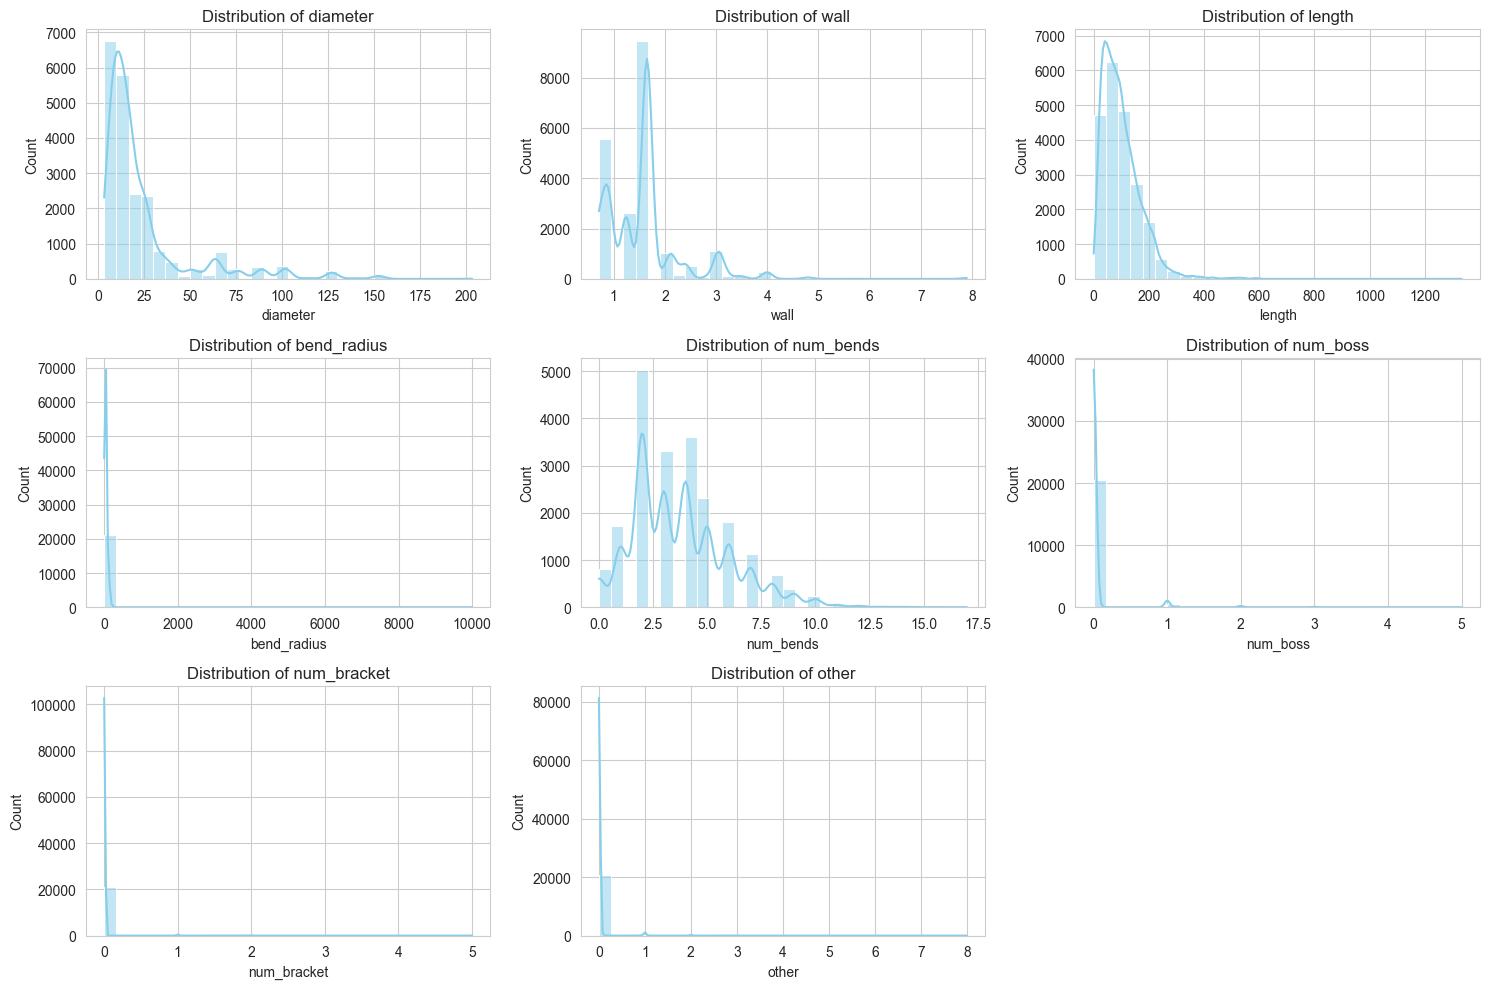

           diameter          wall        length   bend_radius     num_bends  \
count  21198.000000  21198.000000  21198.000000  21198.000000  21198.000000   
mean      23.687764      1.578402    100.312844     49.350767      3.748137   
std       25.396277      0.745749     70.542771    196.468480      2.265405   
min        3.180000      0.710000      0.000000      0.000000      0.000000   
25%        9.520000      0.890000     48.000000     19.050000      2.000000   
50%       15.880000      1.650000     86.000000     38.100000      3.000000   
75%       25.400000      1.650000    135.000000     50.800000      5.000000   
max      203.200000      7.900000   1333.000000   9999.000000     17.000000   

           num_boss   num_bracket         other  
count  21198.000000  21198.000000  21198.000000  
mean       0.044485      0.006746      0.022644  
std        0.260737      0.100015      0.199676  
min        0.000000      0.000000      0.000000  
25%        0.000000      0.000000     

In [23]:


numerical_cols = ['diameter', 'wall', 'length', 'bend_radius', 
                  'num_bends', 'num_boss', 'num_bracket', 'other']

sns.set_style("whitegrid")
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(tube[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Summary Statistics
print(tube[numerical_cols].describe())


## Dataset Bill of Material

Now we continue with the **bill of materials** dataset, which acts as the manufacturing recipe for each product. It lists the specific component identifiers and corresponding quantities required to build every unique tube assembly. We inspect this dataset to understand the physical complexity and component counts making up each industrial assembly.

We start with **bom.shape** to get the dimensions of the matrix, showing us exactly how many assembly records and component tracking columns exist in this raw table.

In [24]:
bom.shape

(21198, 17)

Next, we run **bom.sample(5)** to pull a random selection of 5 complete records, which lets us visually inspect typical data entries across the multiple component and quantity columns.

In [25]:
bom.sample(5)

,tube_assembly_id,component_id_1,quantity_1,component_id_2,quantity_2,component_id_3,quantity_3,component_id_4,quantity_4,component_id_5,quantity_5,component_id_6,quantity_6,component_id_7,quantity_7,component_id_8,quantity_8
2499,TA-02500,C-1630,2.0,C-2028,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15761,TA-15762,C-1624,1.0,C-1631,1.0,C-2005,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8270,TA-08271,C-0444,1.0,C-0445,1.0,C-1479,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5659,TA-05660,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6871,TA-06872,C-1638,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Then, we call **bom.columns** to list all the variable names in the dataset, confirming the structure of component IDs and quantity values from index 1 up to 8.

In [26]:
bom.columns

Index(['tube_assembly_id', 'component_id_1', 'quantity_1', 'component_id_2',
       'quantity_2', 'component_id_3', 'quantity_3', 'component_id_4',
       'quantity_4', 'component_id_5', 'quantity_5', 'component_id_6',
       'quantity_6', 'component_id_7', 'quantity_7', 'component_id_8',
       'quantity_8'],
      dtype='object')

After that, we look at **bom.dtypes** to check the storage formats, verifying whether component labels are recognized as text objects and quantities are stored as numbers.

In [27]:
bom.dtypes

tube_assembly_id     object
component_id_1       object
quantity_1          float64
component_id_2       object
quantity_2          float64
component_id_3       object
quantity_3          float64
component_id_4       object
quantity_4          float64
component_id_5       object
quantity_5          float64
component_id_6       object
quantity_6          float64
component_id_7       object
quantity_7          float64
component_id_8       object
quantity_8          float64
dtype: object

Next, we run **bom.index** to inspect the internal row organization, confirming that the records use a standard, continuous numeric counter.

In [28]:
bom.index

RangeIndex(start=0, stop=21198, step=1)

Then, we combine **pd.concat**([bom.head(), bom.tail()]) to view the first 5 and last 5 rows of the dataset together, allowing us to ensure the loading and visual continuity of the table boundaries.

In [29]:
pd.concat([bom.head(), bom.tail()])

,tube_assembly_id,component_id_1,quantity_1,component_id_2,quantity_2,component_id_3,quantity_3,component_id_4,quantity_4,component_id_5,quantity_5,component_id_6,quantity_6,component_id_7,quantity_7,component_id_8,quantity_8
0,TA-00001,C-1622,2.0,C-1629,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TA-00002,C-1312,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TA-00003,C-1312,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,TA-00004,C-1312,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,TA-00005,C-1624,1.0,C-1631,1.0,C-1641,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21193,TA-21195,C-1373,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21194,TA-21196,C-1364,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21195,TA-21197,C-1733,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21196,TA-21198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21197,TA-21199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


After that, we write **bom.info()** and **bom.describe()** together. The info command gives us a comprehensive overview of non-null counts and memory usage across all structural columns, while the describe command calculates the standard statistical measures for the part counts.

In [30]:
bom.info()
bom.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21198 entries, 0 to 21197
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   tube_assembly_id  21198 non-null  object 
 1   component_id_1    19149 non-null  object 
 2   quantity_1        19149 non-null  float64
 3   component_id_2    14786 non-null  object 
 4   quantity_2        14786 non-null  float64
 5   component_id_3    4791 non-null   object 
 6   quantity_3        4798 non-null   float64
 7   component_id_4    607 non-null    object 
 8   quantity_4        608 non-null    float64
 9   component_id_5    92 non-null     object 
 10  quantity_5        92 non-null     float64
 11  component_id_6    26 non-null     object 
 12  quantity_6        26 non-null     float64
 13  component_id_7    7 non-null      object 
 14  quantity_7        7 non-null      float64
 15  component_id_8    1 non-null      object 
 16  quantity_8        1 non-null      float6

,quantity_1,quantity_2,quantity_3,quantity_4,quantity_5,quantity_6,quantity_7,quantity_8
count,19149.000000,14786.000000,4798.000000,608.000000,92.000000,26.000000,7.0,1.0
mean,1.559873,1.526106,1.020634,1.027961,1.032609,1.153846,1.0,1.0
std,0.507444,0.510851,0.160100,0.209041,0.178583,0.367946,0.0,NaN
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.0
25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.0
50%,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.0
75%,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.0
max,6.000000,6.000000,4.000000,4.000000,2.000000,2.000000,1.0,1.0


Finally, we create a custom statistical graphic to see the overall density of components per unit.

- We start by setting a white grid background layout using **sns.set_style**("whitegrid") for clear readability.

- Then, we use a short list to group all eight individual quantity column names together into a single reference variable called quantity_cols.

- Next, we call **bom[quantity_cols].sum(axis=1)** to horizontally sum the values across these columns for every single row, calculating the grand total of all combined parts for each specific assembly ID.

- After initializing a clear plotting window measuring 10 by 6 inches with plt.figure, we pass this calculated total to sns.histplot to generate a steel-blue distribution chart showing how many assemblies require large versus small amounts of pieces.

- We apply descriptive text labels to our chart using plt.title, plt.xlabel, and plt.ylabel.

To make the plot more informative for analysis, we call plt.axvline to drop a vertical red dashed line indicating the mathematical average number of parts per assembly, and complete the visualization by loading a legend with **plt.legend()** and displaying the final chart on screen with **plt.show().**

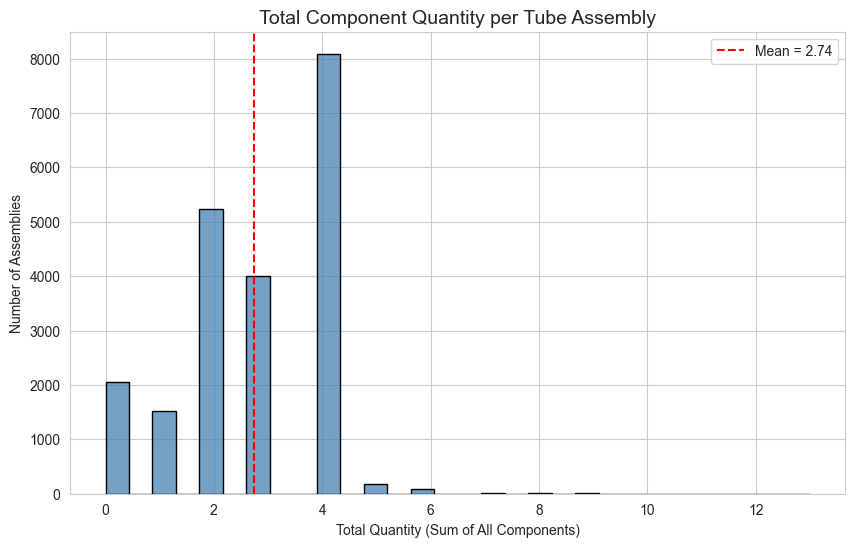

In [31]:
sns.set_style("whitegrid")

# Total Quantity of Components per Assembly
quantity_cols = ['quantity_' + str(i) for i in range(1,9)]
total_quantity = bom[quantity_cols].sum(axis=1)

plt.figure(figsize=(10, 6))
sns.histplot(total_quantity, bins=30, color='steelblue', edgecolor='black')

plt.title('Total Component Quantity per Tube Assembly', fontsize=14)
plt.xlabel('Total Quantity (Sum of All Components)')
plt.ylabel('Number of Assemblies')

# Add some useful stats
plt.axvline(total_quantity.mean(), color='red', linestyle='--', label=f'Mean = {total_quantity.mean():.2f}')
plt.legend()

plt.show()



## Dataset - Specifications

Finally we examine the **technical specifications dataset.** Because different tubes require varying numbers of processing standards, we inspect this dataset to understand how these manufacturing constraints are distributed and organized. 

It is important to highlight that this dataset contains a high percentage of missing values (NaN) across almost all specification columns. This structure is completely normal for manufacturing data, the table provides up to 10 columns to accommodate a few highly complex parts, but the majority of standard tube assemblies require zero or only one special process treatment, leaving the rest of the rows blank. 

We are intentionally loading and inspecting these metrics to audit our data quality.

First, we call **specs.shape** to discover the overall matrix dimensions, confirming the exact row and column configuration of our specification records.

In [32]:
specs.shape

(21198, 11)

Next, we run **specs.sample(3)** to isolate a random group of 3 rows from the table, allowing us to see real examples of how engineering specification codes are populated, this action reveals that many spec variables have the value NaN.

In [33]:
specs.sample(3)

,tube_assembly_id,spec1,spec2,spec3,spec4,spec5,spec6,spec7,spec8,spec9,spec10
18898,TA-18899,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12264,TA-12265,SP-0007,SP-0069,SP-0080,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7354,TA-07355,SP-0007,SP-0012,SP-0024,SP-0026,SP-0080,SP-0082,NaN,NaN,NaN,NaN


Then, we call **specs.columns** to retrieve a complete all the attribute headers, ensuring we understand the exact naming layout of the specification variables.

In [34]:
specs.columns

Index(['tube_assembly_id', 'spec1', 'spec2', 'spec3', 'spec4', 'spec5',
       'spec6', 'spec7', 'spec8', 'spec9', 'spec10'],
      dtype='object')

After that, we view **specs.dtypes** to identify the structural computing data types, verifying that our specification code attributes are successfully read as text or classification objects.

In [35]:
specs.dtypes

tube_assembly_id    object
spec1               object
spec2               object
spec3               object
spec4               object
spec5               object
spec6               object
spec7               object
spec8               object
spec9               object
spec10              object
dtype: object

Next, we run **specs.index** to review the underlying database indexing structure, checking that the sequential row tracking system is correctly initialized.

In [36]:
specs.index

RangeIndex(start=0, stop=21198, step=1)

Then, we execute **specs.info()** and **specs.describe()** together to build a statistical diagnostic summary. The info command details column storage layouts along with absolute non-null counts to highlight empty records, while the describe command evaluates the text data to display the number of unique values, the most frequent codes, and their raw occurrence counts.

In [37]:
specs.info()
specs.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21198 entries, 0 to 21197
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   tube_assembly_id  21198 non-null  object
 1   spec1             7129 non-null   object
 2   spec2             6844 non-null   object
 3   spec3             5840 non-null   object
 4   spec4             4154 non-null   object
 5   spec5             2921 non-null   object
 6   spec6             2071 non-null   object
 7   spec7             535 non-null    object
 8   spec8             106 non-null    object
 9   spec9             20 non-null     object
 10  spec10            1 non-null      object
dtypes: object(11)
memory usage: 1.8+ MB


,tube_assembly_id,spec1,spec2,spec3,spec4,spec5,spec6,spec7,spec8,spec9,spec10
count,21198,7129,6844,5840,4154,2921,2071,535,106,20,1
unique,21198,45,51,49,38,37,24,13,4,3,1
top,TA-00001,SP-0007,SP-0012,SP-0080,SP-0026,SP-0080,SP-0082,SP-0082,SP-0082,SP-0088,SP-0080
freq,1,3002,1736,1798,1492,1780,1167,322,73,18,1


Finally, we run **pd.concat** to stack the top 5 records and the bottom 5 records into a single display layout, enabling us to verify visual continuity and format alignment across both extreme borders of the file.

In [38]:
pd.concat([specs.head(), specs.tail()])

,tube_assembly_id,spec1,spec2,spec3,spec4,spec5,spec6,spec7,spec8,spec9,spec10
0,TA-00001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TA-00002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TA-00003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,TA-00004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,TA-00005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21193,TA-21195,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21194,TA-21196,SP-0007,SP-0080,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21195,TA-21197,SP-0007,SP-0080,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21196,TA-21198,SP-0058,SP-0080,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21197,TA-21199,SP-0058,SP-0080,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Verify Data Quality

**This major section covers our data quality and integrity audit**

Before merging our relational source tables or applying any advanced analytics, we must systematically verify the statistical completeness and unique row structure of each dataset. 

This validation step ensures that missing text entries, blank numerical fields, or accidental duplicate records are caught and evaluated early, protecting the reliability and consistency of our pricing analysis.

## Missing Values

Now we begin a process to find **missing data gaps** and identify duplicated rows across all four independent tables. 

This allow us to evaluate the structural health of our files and determine whether we need to apply data cleaning corrections, or simply leave columns alone based on their engineering characteristics.

### Tube Dataset Missing Values and Duplicates

First, we call **tube.isnull().sum()** which scans every single row and column within the tube properties table, flags any empty cells, and prints out a clear summary of missing counts for each feature to confirm if any dimension was left unrecorded.

In [39]:
tube.isnull().sum()

tube_assembly_id      0
material_id         279
diameter              0
wall                  0
length                0
num_bends             0
bend_radius           0
end_a_1x              0
end_a_2x              0
end_x_1x              0
end_x_2x              0
end_a                 0
end_x                 0
num_boss              0
num_bracket           0
other                 0
dtype: int64

Second, we execute **tube.duplicated().sum()** to cross-match all rows horizontally against each other, calculating if any identical physical entries were repeated by mistake in the data.

In [40]:
tube.duplicated().sum()

np.int64(0)

Now we check our primary commercial supplier training set to verify its overall data cleanliness before modeling.

First, we execute **train.isnull().sum()** to calculate the total number of missing blank spaces in our supplier quote records, ensuring that essential attributes like pricing codes, quote dates, annual volume requirements, and final benchmark costs are completel.

### Train Dataset Missing Values and Duplicates

In [41]:
train.isnull().sum()

tube_assembly_id      0
supplier              0
quote_date            0
annual_usage          0
min_order_quantity    0
bracket_pricing       0
quantity              0
cost                  0
dtype: int64

Then, we run train.duplicated().sum() to verify that there are no duplicated quote transactions in our training baseline, confirming that every record represents an independent commercial data point.

In [42]:
train.duplicated().sum()

np.int64(0)

Now we look into the data of our technical engineering specifications table to confirm our earlier assessment.

We call again **specs.isnull().sum()** to verify the exact number of blank cells per column.

### Specification Dataset Missing values and Duplicates

In [43]:
specs.isnull().sum()

tube_assembly_id        0
spec1               14069
spec2               14354
spec3               15358
spec4               17044
spec5               18277
spec6               19127
spec7               20663
spec8               21092
spec9               21178
spec10              21197
dtype: int64

We run specs.duplicated().sum() to inspect whether any completely identical specification row sequences are present in the database.

In [44]:
specs.duplicated().sum()

np.int64(0)

Now we analyze our **component assembly data** to verify that its inventory listings are clean and structurally sound.

We run **bom.isnull().sum()** to scan all the component identities and quantity listings, showing us where the unassigned slots are located so we can safely prepare to handle these empty positions in our next manufacturing weight calculation steps.

### Bill of Material missing values and Duplicates

In [45]:
bom.isnull().sum()


tube_assembly_id        0
component_id_1       2049
quantity_1           2049
component_id_2       6412
quantity_2           6412
component_id_3      16407
quantity_3          16400
component_id_4      20591
quantity_4          20590
component_id_5      21106
quantity_5          21106
component_id_6      21172
quantity_6          21172
component_id_7      21191
quantity_7          21191
component_id_8      21197
quantity_8          21197
dtype: int64

Finally, we execute **bom.duplicated().sum()** to check for any repeated rows inside our component recipes table, verifying that each unique tube assembly possesses only one distinct bill of materials record.

In [46]:
bom.duplicated().sum()

np.int64(0)

## Merging Relational Datasets Using Tube Assembly ID

This section covers the process of linking and consolidating our separate relational database tables. By using the shared unique assembly key, we merge our commercial transactions table with the technical geometry database to create a combined workspace. 

- We then run a series of integrity cross-checks, analyze supplier distributions, inspect historical time groupings, and calculate statistical correlations to see how combined features impact assembly costs.

- First, we use pd.merge to join our main commercial table and our technical geometry table together on their shared matching key column. This operation saves the combined results into a new master table called NewTrain.

In [47]:
NewTrain = pd.merge(train, tube, on ='tube_assembly_id')

Then, we run **NewTrain.info()** to extract a summary of our newly combined dataset, allowing us to confirm the new row count, verify column alignments, and inspect the unified database file storage size.

In [48]:
NewTrain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30213 entries, 0 to 30212
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   tube_assembly_id    30213 non-null  object        
 1   supplier            30213 non-null  object        
 2   quote_date          30213 non-null  datetime64[ns]
 3   annual_usage        30213 non-null  int64         
 4   min_order_quantity  30213 non-null  int64         
 5   bracket_pricing     30213 non-null  object        
 6   quantity            30213 non-null  int64         
 7   cost                30213 non-null  float64       
 8   material_id         29984 non-null  object        
 9   diameter            30213 non-null  float64       
 10  wall                30213 non-null  float64       
 11  length              30213 non-null  float64       
 12  num_bends           30213 non-null  int64         
 13  bend_radius         30213 non-null  float64   

Then, we call **NewTrain.tube_assembly_id.nunique()** to compute the absolute total number of unique part identification codes present in our integrated training rows, checking the core variety of our parts inventory.

In [49]:
# No.of unique tube assumblies
NewTrain.tube_assembly_id.nunique()

8855

After that, we calculate **missing_in_tube** to find any commercial transaction codes that are missing a matching record in our registry. Printing this result helps us ensure that every sales quote possesses a technical drawing.

In [50]:
missing_in_tube = set(train['tube_assembly_id']) - set(tube['tube_assembly_id'])
print(len(missing_in_tube))

0


Similarly, we run **missing_in_train** to discover any engineered tube parts that do not possess a corresponding entry in our bidding table, showing us parts that have not yet received supplier price quotes.

In [51]:
missing_in_train = set(tube['tube_assembly_id']) - set(train['tube_assembly_id'])
print(len(missing_in_train))

12343


Next, we look at supplier distributions by calling **NewTrain.supplier.nunique()** to count exactly how many **unique raw material** and component suppliers are participating in our current procurement dataset.

In [52]:
# How many unique suppliers are there?
NewTrain.supplier.nunique()

57

Then, we run a grouping command using **NewTrain.groupby**('tube_assembly_id')['supplier'].value_counts() to view exactly which suppliers submitted commercial quotes for each individual tube component code, helping us analyze supplier competition per part.

In [53]:
# Quote received from each supplier for each component
NewTrain.groupby('tube_assembly_id')['supplier'].value_counts()

tube_assembly_id  supplier
TA-00002          S-0066      8
TA-00004          S-0066      8
TA-00005          S-0066      8
TA-00012          S-0066      8
TA-00013          S-0026      1
                             ..
TA-21190          S-0041      1
TA-21191          S-0041      1
TA-21195          S-0041      1
TA-21196          S-0062      1
TA-21197          S-0026      1
Name: count, Length: 8908, dtype: int64

Following that, we rank our suppliers using **NewTrain.groupby**('supplier')['tube_assembly_id'].nunique().sort_values(ascending=False) which counts how many unique tube codes each vendor supplies and sorts them from highest to lowest to show us our top volume suppliers.

In [54]:
# Ranking suppliers by no. of tube assembly each supplier supplies
NewTrain.groupby('supplier')['tube_assembly_id'].nunique().sort_values(ascending=False)

supplier
S-0066    3530
S-0041    1536
S-0072    1459
S-0026     552
S-0013     535
S-0058     252
S-0064     195
S-0062     176
S-0054     152
S-0030     103
S-0104      90
S-0081      54
S-0014      52
S-0105      33
S-0005      24
S-0031      18
S-0070      16
S-0027      15
S-0043      14
S-0042      13
S-0018      10
S-0092       9
S-0007       5
S-0015       5
S-0011       5
S-0009       4
S-0023       4
S-0059       4
S-0025       3
S-0060       3
S-0096       2
S-0078       2
S-0046       2
S-0111       2
S-0107       2
S-0080       2
S-0074       2
S-0087       2
S-0061       2
S-0056       2
S-0012       1
S-0029       1
S-0024       1
S-0022       1
S-0003       1
S-0006       1
S-0004       1
S-0008       1
S-0051       1
S-0068       1
S-0050       1
S-0095       1
S-0090       1
S-0106       1
S-0097       1
S-0108       1
S-0109       1
Name: tube_assembly_id, dtype: int64

Next, we check our historical quote data over time. 

- We apply **sns.set_style("whitegrid")** for a clear plotting background grid. 

- We isolate the baseline year by using the **.dt.year** date-time extractor on our quote dates, and compress these records into 5-year buckets by running a mathematical flooring division. 

- We count the occurrences in each bucket using **.value_counts().sort_index()** and store them inside **five_year.**

- We initialize a **10 by 6 inch** plotting window using **plt.figure,** call **five_year.plot(kind='bar')** to construct a vertical bar chart tracking the volume of quotes across historical eras, add clear axis text labels with plt.title, plt.xlabel, and plt.ylabel, build clear custom date range strings to replace default index ticks with plt.xticks

- We add a horizontal red dashed line mapping the overall average quote volume per era with plt.axhline, include a descriptive legend block using **plt.legend(),** clean up label spacing via **plt.tight_layout(),** and project the visualization to the screen with plt.show() before printing out raw historical summary numbers.

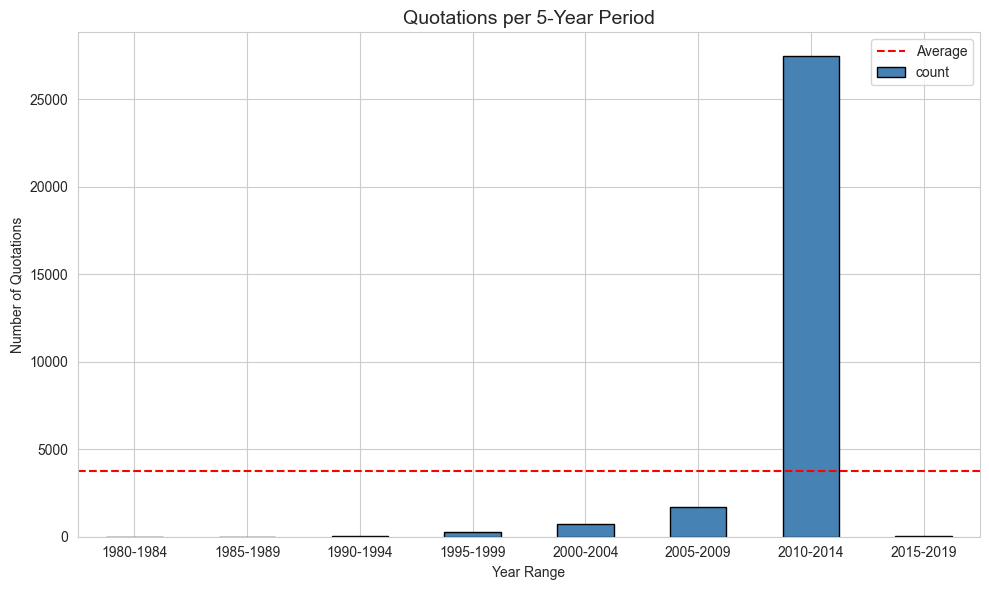

year_group
1980        6
1985        5
1990       18
1995      246
2000      750
2005     1697
2010    27465
2015       26
Name: count, dtype: int64

Total Quotes: 30213


In [55]:
#Qutation Period 

sns.set_style("whitegrid")

# Create 5-year bins
NewTrain['year'] = NewTrain['quote_date'].dt.year
NewTrain['year_group'] = (NewTrain['year'] // 5) * 5

# Count quotations per 5-year period
five_year = NewTrain['year_group'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
five_year.plot(kind='bar', color='steelblue', edgecolor='black')

plt.title('Quotations per 5-Year Period', fontsize=14)
plt.xlabel('Year Range')
plt.ylabel('Number of Quotations')

# Better x-axis labels
labels = [f"{int(y)}-{int(y+4)}" for y in five_year.index]
plt.xticks(range(len(five_year)), labels, rotation=0)

plt.axhline(y=five_year.mean(), color='red', linestyle='--', label='Average')
plt.legend()
plt.tight_layout()
plt.show()

# Summary
print(five_year)
print("\nTotal Quotes:", len(NewTrain))

**Finally, we analyze linear statistical relationships.**

- We define a list called numeric_cols containing all key independent continuous features, pass this subset to **.corr()** to compute an overarching correlation matrix, and isolate cost_corr to focus entirely on values linked to final item costs.

- We open a 12 by 8 inch canvas using **plt.figure,** call **sns.heatmap** to draw a color-coded matrix map where positive correlations show up as warm colors and negative correlations show up as cool colors. 

- Then, set numeric data tags inside cells with **annot=True** formatted to two decimal points, apply clean text titles, rotate our horizontal and vertical text headings for easier reading, structure the spacing cleanly using **plt.tight_layout(),** and print the final plot using **plt.show().**

- We finish by outputting a summary table using **print(cost_corr.round(3))** to instantly review which specific technical parameters display the strongest statistical links to final component costs.

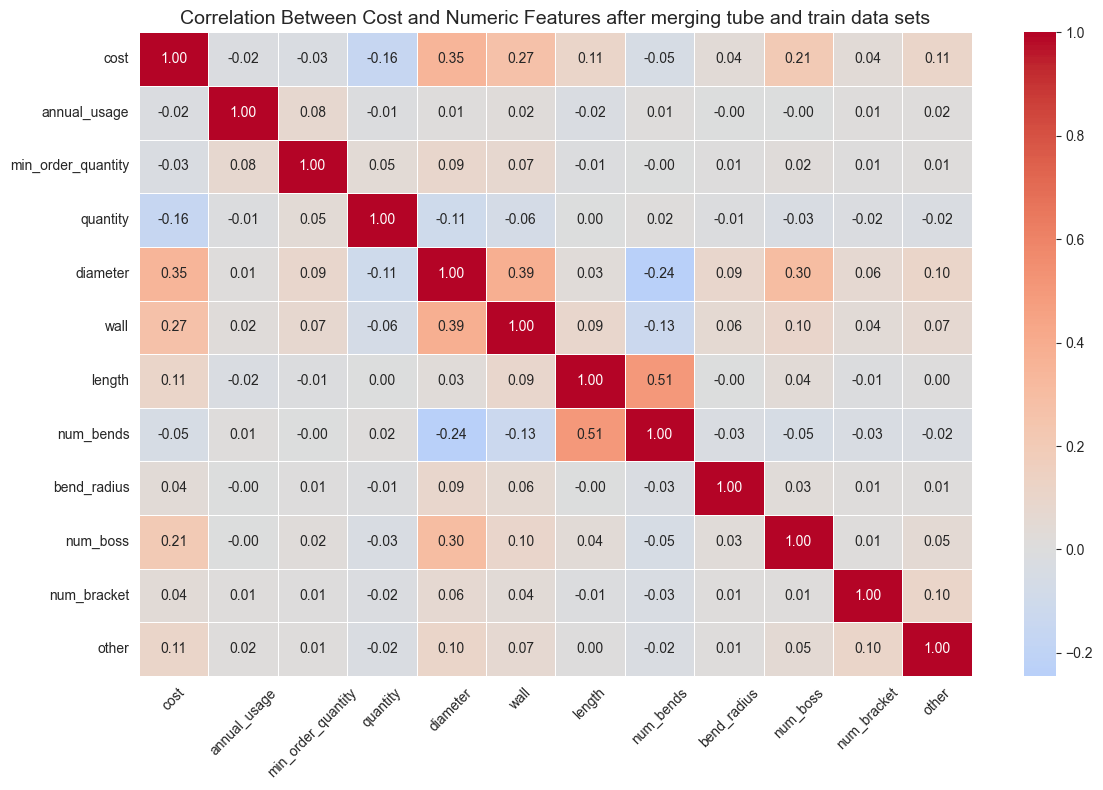

=== Top Features Correlated with Cost ===

cost                  1.000
diameter              0.348
wall                  0.267
num_boss              0.207
length                0.108
other                 0.107
num_bracket           0.040
bend_radius           0.038
annual_usage         -0.018
min_order_quantity   -0.030
num_bends            -0.054
quantity             -0.162
Name: cost, dtype: float64


In [56]:
# Select numeric columns only
numeric_cols = ['cost', 'annual_usage', 'min_order_quantity', 'quantity', 
                'diameter', 'wall', 'length', 'num_bends', 'bend_radius', 
                'num_boss', 'num_bracket', 'other']

# Correlation Matrix
corr = NewTrain[numeric_cols].corr()

# Focus on correlation with 'cost'
cost_corr = corr['cost'].sort_values(ascending=False)

plt.figure(figsize=(12, 8))

# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=0.5)

plt.title('Correlation Between Cost and Numeric Features after merging tube and train data sets', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Top Correlations with Cost (Summary Table)
print("=== Top Features Correlated with Cost ===\n")
print(cost_corr.round(3))

# Preliminary Feature Engineering

This major section begins our feature engineering phase, which is one of the most critical steps in preparing data for machine learning models. 

Machine learning algorithms cannot natively interpret complex date strings or raw text strings. 

In this phase, we mathematically convert, extract, and enrich our columns to expose hidden patterns—such as time trends or part geometries—directly to our predictive models to increase accuracy.

We begin by initialize our core data transformation utility tool. We load the LabelEncoder module from the scikit-learn library, and we instantiate it as a shortened object named le. 

This tool will automatically scan non-numeric text categories and swap them into structured whole numbers.

In [57]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

## Adding new columns for date seperated by day, month and year

This subsection breaks down our complex supplier quote date column into distinct time components. 

A raw date cannot be easily calculated by an **algorithm,** but separating it allows the model to isolate independent seasonal trends, monthly shifts, or yearly inflation patterns.

Now we apply **time-extraction** commands to break down our main quote date column into five highly specific numeric attributes inside our master NewTrain dataset.

- First, we use the .dt.year property on our quote_date variable to extract the exact calendar year and store it in a clean column called year.

- Next, we run .dt.month to capture the chronological month index from 1 to 12 and map it into a column named month.

- Then, we run .dt.dayofyear to extract the exact sequential calendar day number, ranging from 1 up to 365, saving it as dayofyear.

- After that, we run .dt.dayofweek to calculate the specific business day index of the week, ranging from 0 for Monday up to 6 for Sunday, storing it as dayofweek.

- Next, we execute .dt.day to isolate the exact day number of the month, from 1 to 31, saving it into a variable called day.

In [58]:
NewTrain['year'] = NewTrain.quote_date.dt.year
NewTrain['month'] = NewTrain.quote_date.dt.month
NewTrain['dayofyear'] = NewTrain.quote_date.dt.dayofyear
NewTrain['dayofweek'] = NewTrain.quote_date.dt.dayofweek
NewTrain['day'] = NewTrain.quote_date.dt.day

Finally, we run **NewTrain.head()** to inspect the top 5 records of our updated table.

In [59]:
NewTrain.head()

,tube_assembly_id,supplier,quote_date,annual_usage,min_order_quantity,bracket_pricing,quantity,cost,material_id,diameter,...,end_x,num_boss,num_bracket,other,year,year_group,month,dayofyear,dayofweek,day
0,TA-00002,S-0066,2013-07-07,0,0,Yes,1,21.905933,SP-0019,6.35,...,EF-008,0,0,0,2013,2010,7,188,6,7
1,TA-00002,S-0066,2013-07-07,0,0,Yes,2,12.341214,SP-0019,6.35,...,EF-008,0,0,0,2013,2010,7,188,6,7
2,TA-00002,S-0066,2013-07-07,0,0,Yes,5,6.601826,SP-0019,6.35,...,EF-008,0,0,0,2013,2010,7,188,6,7
3,TA-00002,S-0066,2013-07-07,0,0,Yes,10,4.687770,SP-0019,6.35,...,EF-008,0,0,0,2013,2010,7,188,6,7
4,TA-00002,S-0066,2013-07-07,0,0,Yes,25,3.541561,SP-0019,6.35,...,EF-008,0,0,0,2013,2010,7,188,6,7


Followed by **NewTrain.columns** to display our full layout index, ensuring that all 5 brand-new calendar attributes have been successfully appended to the right side of the database matrix.

In [60]:
NewTrain.columns

Index(['tube_assembly_id', 'supplier', 'quote_date', 'annual_usage',
       'min_order_quantity', 'bracket_pricing', 'quantity', 'cost',
       'material_id', 'diameter', 'wall', 'length', 'num_bends', 'bend_radius',
       'end_a_1x', 'end_a_2x', 'end_x_1x', 'end_x_2x', 'end_a', 'end_x',
       'num_boss', 'num_bracket', 'other', 'year', 'year_group', 'month',
       'dayofyear', 'dayofweek', 'day'],
      dtype='object')

## Encoding categorical text values into number

This subsection handles categorical binary text features. 

In our manufacturing data, parameters like bracket pricing models and specific industrial line extensions are recorded using text tags like "Y" for Yes and "N" for No. We must transform these into a standard numeric format.

- First, we use **le.fit_transform** on the **bracket_pricing** feature to turn its string fields into numbers, automatically re-saving the results to override the original column.

- Next, we run the same transformation on the manufacturing flag variables end_a_1x, end_a_2x, end_x_1x, and end_x_2x, systematically converting all raw text flags into clean digits, enabling our machine learning models to calculate their structural impact on pricing.

In [61]:
# the text values of Y and N are transofrmed to 0 and 1
NewTrain['bracket_pricing'] = le.fit_transform(NewTrain.bracket_pricing)
NewTrain['end_a_1x'] = le.fit_transform(NewTrain.end_a_1x)
NewTrain['end_a_2x'] = le.fit_transform(NewTrain.end_a_2x)
NewTrain['end_x_1x'] = le.fit_transform(NewTrain.end_x_1x)
NewTrain['end_x_2x'] = le.fit_transform(NewTrain.end_x_2x)

## Read the look up value for the column end_a and end_x from the look up table tube_end_form to check if there is forming and add relevant column in new dataset NewTrain

This subsection performs an advanced domain-specific lookup operation. 

Tube assembly ends frequently with structural shapes manipulation called "forming" to connect cleanly with other machinery. 

We pull data from an external look-up table to identify whether the connection pieces at both ends of each tube require special forming fabrication.

First, we use the **pd.read_csv** function to load the secondary reference file named **tube_end_form.csv** into a temporary reference table named end_form, and we run **end_form.head()** to visually inspect its layout.

In [62]:
end_form = pd.read_csv(r"C:\Users\nweke\Downloads\tube_end_form.csv")
end_form.head()

,end_form_id,forming
0,EF-001,Yes
1,EF-002,No
2,EF-003,No
3,EF-004,No
4,EF-005,Yes


Next, we take the forming column inside that new reference table and apply **le.fit_transform** to convert its descriptive text tags into digits.

In [63]:
# Lable encode 'forming' in the look up table of end_form
end_form['forming'] = le.fit_transform(end_form.forming)

Then, we perform our main mapping link. We use NewTrain['end_a'].map while pointing to our look-up table after setting its index to the unique end_form_id. 

This searches the master tube's end_a connection type, finds out if it requires forming, and logs the result inside a new column called end_a_forming.

We replicate the exact same logic for the opposite side of the tube by running a map command on end_x, saving the resulting classification indicator as end_x_forming.

In [64]:
# Map 'forming' value onto 'end_a' and 'end_x' columns of our NewTrain dataset
NewTrain['end_a_forming'] = NewTrain['end_a'].map(end_form.set_index('end_form_id')['forming']) # 1 if there is forming, 0 otherwise
NewTrain['end_x_forming'] = NewTrain['end_x'].map(end_form.set_index('end_form_id')['forming'])


Finally, we execute **NewTrain.columns** to review our updated column directory, verifying that both end formation features are properly integrated into our primary workspace.

In [65]:
# check if new columns added 
NewTrain.columns

Index(['tube_assembly_id', 'supplier', 'quote_date', 'annual_usage',
       'min_order_quantity', 'bracket_pricing', 'quantity', 'cost',
       'material_id', 'diameter', 'wall', 'length', 'num_bends', 'bend_radius',
       'end_a_1x', 'end_a_2x', 'end_x_1x', 'end_x_2x', 'end_a', 'end_x',
       'num_boss', 'num_bracket', 'other', 'year', 'year_group', 'month',
       'dayofyear', 'dayofweek', 'day', 'end_a_forming', 'end_x_forming'],
      dtype='object')

### Remove the missing values from new added forming columns

This subsection covers our localized data quality cleanup for our newly mapped columns. 

Because some tube assemblies are entirely open-ended or use basic connection shapes that don't exist in the formal engineering lookup register, our mapping command produces a few empty cells which must be corrected.

Now we diagnose and eliminate missing blanks from our newly created engineering attributes.

First, we call **NewTrain.isnull().sum()** to inspect our complete master list, revealing that our newly created **end_a_forming** and **end_x_forming** metrics have introduced some blank null cells.

In [66]:
# check for missing values in new columns
NewTrain.isnull().sum()

tube_assembly_id         0
supplier                 0
quote_date               0
annual_usage             0
min_order_quantity       0
bracket_pricing          0
quantity                 0
cost                     0
material_id            229
diameter                 0
wall                     0
length                   0
num_bends                0
bend_radius              0
end_a_1x                 0
end_a_2x                 0
end_x_1x                 0
end_x_2x                 0
end_a                    0
end_x                    0
num_boss                 0
num_bracket              0
other                    0
year                     0
year_group               0
month                    0
dayofyear                0
dayofweek                0
day                      0
end_a_forming          926
end_x_forming         1315
dtype: int64

Secondly, we apply the **.fillna(0)** function targeting these two specific columns, which safely overwrites those empty blanks with a whole number 0. This is an accurate engineering choice because if an end piece does not appear in the forming registry, it means no special fabrication work is performed on it.

In [67]:
# Fill null value with 0, as no ends means no forming)
NewTrain[['end_a_forming', 'end_x_forming']] = NewTrain[['end_a_forming', 'end_x_forming']].fillna(0)

Third, we run **NewTrain.isnull().sum()** a second time to ensure that our fill command was executed properly and that our empty cells have dropped to zero.

In [68]:
NewTrain.isnull().sum()

tube_assembly_id        0
supplier                0
quote_date              0
annual_usage            0
min_order_quantity      0
bracket_pricing         0
quantity                0
cost                    0
material_id           229
diameter                0
wall                    0
length                  0
num_bends               0
bend_radius             0
end_a_1x                0
end_a_2x                0
end_x_1x                0
end_x_2x                0
end_a                   0
end_x                   0
num_boss                0
num_bracket             0
other                   0
year                    0
year_group              0
month                   0
dayofyear               0
dayofweek               0
day                     0
end_a_forming           0
end_x_forming           0
dtype: int64

Finally, we execute **NewTrain.head()** to view the updated rows, confirming that our numbers, time variables, and engineering tags are fully aligned and complete.

In [69]:
NewTrain.head()

,tube_assembly_id,supplier,quote_date,annual_usage,min_order_quantity,bracket_pricing,quantity,cost,material_id,diameter,...,num_bracket,other,year,year_group,month,dayofyear,dayofweek,day,end_a_forming,end_x_forming
0,TA-00002,S-0066,2013-07-07,0,0,1,1,21.905933,SP-0019,6.35,...,0,0,2013,2010,7,188,6,7,1.0,1.0
1,TA-00002,S-0066,2013-07-07,0,0,1,2,12.341214,SP-0019,6.35,...,0,0,2013,2010,7,188,6,7,1.0,1.0
2,TA-00002,S-0066,2013-07-07,0,0,1,5,6.601826,SP-0019,6.35,...,0,0,2013,2010,7,188,6,7,1.0,1.0
3,TA-00002,S-0066,2013-07-07,0,0,1,10,4.687770,SP-0019,6.35,...,0,0,2013,2010,7,188,6,7,1.0,1.0
4,TA-00002,S-0066,2013-07-07,0,0,1,25,3.541561,SP-0019,6.35,...,0,0,2013,2010,7,188,6,7,1.0,1.0


## Determinig Total quanitiy and weight of tube from Dataset bill of material

This subsection implements advanced manufacturing feature engineering by extracting complex indicators from our bill of materials dataset. 

- In industrial analytics, a tube's final price is heavily dictated by its overall material complexity, total piece attachments, and collective structural mass. 

- The raw bill of materials lists individual component ID strings, and their matching volumes across alternating columns.

- We must design programmatic loops to automatically resolve these records, find the individual parts who heavy weight properties from 11 separate sub-component source catalogs, and aggregate them into clear metrics tracking total part counts and absolute total tube assembly weights.


First, we call **bom.head()** to examine the layout of our raw item list and inspect how component identities and quantity arrays.

In [70]:
bom.head()

,tube_assembly_id,component_id_1,quantity_1,component_id_2,quantity_2,component_id_3,quantity_3,component_id_4,quantity_4,component_id_5,quantity_5,component_id_6,quantity_6,component_id_7,quantity_7,component_id_8,quantity_8
0,TA-00001,C-1622,2.0,C-1629,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TA-00002,C-1312,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TA-00003,C-1312,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,TA-00004,C-1312,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,TA-00005,C-1624,1.0,C-1631,1.0,C-1641,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Next, we execute **bom.fillna(0, inplace=True)** to immediately replace all empty cells inside our parts ledger with a number 0. This is an essential preparation step to ensure that  column addition and multiplication math equations do not encounter blank values and crash.

- Then, we perform a **horizontal matrix** calculation by running bom['Total_quantity'] = bom.iloc[:, 2::2].sum(axis=1). 

- This script utilizes integer slicing to isolate only columns tracking numeric volumes (starting at index 2 and skipping every second column forward) and sums them across rows to isolate the absolute total number of sub-components attached to each tube assembly identifier.

After that, we run **bom.head()** to verify that our new quantity summary column has been correctly built and attached on the right hand side.

In [71]:
bom.fillna(0,inplace=True)

In [72]:
# Starting from 'quantity_1', we sum up quantities every other columns
bom['Total_quantity'] = bom.iloc[:, 2::2].sum(axis=1) 

In [73]:
bom.head()

,tube_assembly_id,component_id_1,quantity_1,component_id_2,quantity_2,component_id_3,quantity_3,component_id_4,quantity_4,component_id_5,quantity_5,component_id_6,quantity_6,component_id_7,quantity_7,component_id_8,quantity_8,Total_quantity
0,TA-00001,C-1622,2.0,C-1629,2.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,4.0
1,TA-00002,C-1312,2.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,2.0
2,TA-00003,C-1312,2.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,2.0
3,TA-00004,C-1312,2.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,2.0
4,TA-00005,C-1624,1.0,C-1631,1.0,C-1641,1.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,3.0


Next, we create a custom data harvesting tool by defining a python function called **def get_comp_weight().**

- Inside this, we create a list named comp_names tracking all 11 distinct manufacturing hardware categories, such as adaptors, bosses, elbows, nuts, and sleeves. 

We initialize an empty global workspace table, loop through each item in the category list to programmatically pull its corresponding specific CSV data sheet, extract only its identification code and individual weight column, and stack them continuously using pd.concat into an integrated global weights directory named **comp_dfs.**

In [74]:
# we use for in loop to select comp name from the bracket and import its dataset in data from comp_df and than only pick the data related to comp_id and its weight in a new dataframe called camp_dfs
#This function loops through multiple component CSV files, extracts component IDs and weights, and merges them into one unified DataFrame.

def get_comp_weight():
    
    comp_names = ['adaptor', 'boss', 'elbow', 'float', 
                  'hfl', 'nut', 'other', 'sleeve',
                  'straight', 'tee', 'threaded']

    comp_dfs = pd.DataFrame()
    for comp_name in comp_names:
        comp_df = pd.read_csv(r"C:\Users\nweke\Downloads\comp_" + comp_name + ".csv")
        comp_dfs = pd.concat([comp_dfs, comp_df[['component_id', 'weight']]])

    return comp_dfs

Then, we execute **comp_dfs = get_comp_weight()** to run our custom automated multi-file harvesting engine, parsing all sub-component specifications at once.

Following that, we call **comp_dfs.info()** to check our newly collected hardware index, reviewing the text configurations, data footprint, and layout of our unified master weight dataset.

In [75]:
comp_dfs = get_comp_weight()

In [76]:
comp_dfs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2047 entries, 0 to 193
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   component_id  2047 non-null   object 
 1   weight        1976 non-null   float64
dtypes: float64(1), object(1)
memory usage: 48.0+ KB


Next, we run **comp_dfs['weight'] = comp_dfs['weight'].fillna(0)** to convert any unlogged or missing individual hardware weight values to 0, ensuring that minor missing sub-part entries do not corrupt our final mathematical summary.

In [77]:
# Fill missing values with 0 in weigt columns
comp_dfs['weight'] = comp_dfs['weight'].fillna(0)

Then, we run a programmatic mapping loop across all eight possible component slots from **1 to 8. **

In each cycle of this loop, the script targets the string ID values inside the raw assembly columns and replaces them with their actual physical unit weight extracted from our unified hardware dictionary index using the **.map function.**

In [78]:
# we used a look to Replace component_id columns with respective weight
for i in range(1,9):
    comp_no = 'component_id_'+str(i)
    bom[comp_no] = bom[comp_no].map(comp_dfs.set_index('component_id')['weight'])

After completing the conversion loop, we execute **bom.sample(10, random_state=42**) to randomly pull **10 distinct items** from our workspace, verifying that our alphanumeric identifier slots have been successfully transformed into numerical weights.

In [79]:
bom.sample(10, random_state=42)

,tube_assembly_id,component_id_1,quantity_1,component_id_2,quantity_2,component_id_3,quantity_3,component_id_4,quantity_4,component_id_5,quantity_5,component_id_6,quantity_6,component_id_7,quantity_7,component_id_8,quantity_8,Total_quantity
11648,TA-11649,0.035,2.0,0.026,2.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,4.0
8072,TA-08073,0.104,2.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,2.0
16658,TA-16659,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,0.0
7934,TA-07935,0.035,2.0,0.026,2.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,4.0
18217,TA-18218,0.015,2.0,0.006,2.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,4.0
2361,TA-02362,0.009,2.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,2.0
17068,TA-17069,0.036,2.0,0.012,2.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,4.0
6024,TA-06025,0.036,2.0,0.012,2.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,4.0
9038,TA-09039,0.129,1.0,0.033,1.0,0.390,1.0,0.021,1.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,4.0
21099,TA-21101,0.009,1.0,0.046,1.0,0.236,1.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,3.0


Next, we execute our grand total structural weight equation. 

We set our baseline target column **bom['Total_weight'] = 0,** and initiate an iterative loop running **from 1 to 8.** 

In every cycle, the function isolates a component slot, multiplies its mapped unit weight variable by its required quantity value, and maintains a continuous running sum to calculate the total physical mass of the finished tube assembly.

In [80]:
bom.fillna(0, inplace=True)

# Calculate total weight for each tube

bom['Total_weight'] = 0
for i in range(1,9):
    comp_no = 'component_id_'+ str(i)
    quant_no = 'quantity_'+ str(i)
    
    bom['Total_weight'] = bom['Total_weight'] + bom[comp_no]*bom[quant_no]

Then, we call **bom.sample(10, random_state=42)** to perform a second randomized review of 10 rows, enabling us to visually confirm that our final mathematical accumulation looks clean and correct.

In [81]:
bom.sample(10, random_state=42)

,tube_assembly_id,component_id_1,quantity_1,component_id_2,quantity_2,component_id_3,quantity_3,component_id_4,quantity_4,component_id_5,quantity_5,component_id_6,quantity_6,component_id_7,quantity_7,component_id_8,quantity_8,Total_quantity,Total_weight
11648,TA-11649,0.035,2.0,0.026,2.0,0.000,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.122
8072,TA-08073,0.104,2.0,0.000,0.0,0.000,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.208
16658,TA-16659,0.000,0.0,0.000,0.0,0.000,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
7934,TA-07935,0.035,2.0,0.026,2.0,0.000,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.122
18217,TA-18218,0.015,2.0,0.006,2.0,0.000,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.042
2361,TA-02362,0.009,2.0,0.000,0.0,0.000,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.018
17068,TA-17069,0.036,2.0,0.012,2.0,0.000,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.096
6024,TA-06025,0.036,2.0,0.012,2.0,0.000,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.096
9038,TA-09039,0.129,1.0,0.033,1.0,0.390,1.0,0.021,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.573
21099,TA-21101,0.009,1.0,0.046,1.0,0.236,1.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.291


Finally, we run **bom.to_csv('bom_final.csv')** to export and save our freshly compiled, feature-engineered bill of materials dataset as a standalone CSV file to avoid losing our engineered weight calculations.

In [82]:
# Save bom to file for later use
bom.to_csv('bom_final.csv')

### Merging dataset bom with the NewTrain dataset ( initial version:train) and name as Final_DF

This subsection covers the final step of our relational database tables and the text-cleaning phase of our core identifier columns. 

We merge our previously generated commercial and physical table (NewTrain) with our newly feature-engineered component weights database (bom) to create a unified master dataframe named **Final_DF.** 

- Then, we perform text splitting operations to convert alphanumeric tracking IDs (like TA-00001 or S-0007) into pure numeric digits so that our machine learning models can process them mathematically without parsing string prefixes.

- First, we use the pd.merge function to combine our commercial dataset and our engineered bill of materials table together using their shared index column tube_assembly_id, creating our absolute master matrix named Final_DF. 

We immediately call Final_DF.info() to verify the newly consolidated dimensions.

In [83]:
Final_DF = pd.merge(NewTrain, bom, on ='tube_assembly_id')
Final_DF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30213 entries, 0 to 30212
Data columns (total 49 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   tube_assembly_id    30213 non-null  object        
 1   supplier            30213 non-null  object        
 2   quote_date          30213 non-null  datetime64[ns]
 3   annual_usage        30213 non-null  int64         
 4   min_order_quantity  30213 non-null  int64         
 5   bracket_pricing     30213 non-null  int64         
 6   quantity            30213 non-null  int64         
 7   cost                30213 non-null  float64       
 8   material_id         29984 non-null  object        
 9   diameter            30213 non-null  float64       
 10  wall                30213 non-null  float64       
 11  length              30213 non-null  float64       
 12  num_bends           30213 non-null  int64         
 13  bend_radius         30213 non-null  float64   

Next, we run **Final_DF.to_csv('Final_DF.csv')** to export a backup copy of this combined matrix, and call **Final_DF.head()** to inspect the alignment of the merged attributes.

In [84]:
# export and save Final_DF
Final_DF.to_csv('Final_DF.csv')

In [85]:
Final_DF.head()

,tube_assembly_id,supplier,quote_date,annual_usage,min_order_quantity,bracket_pricing,quantity,cost,material_id,diameter,...,component_id_5,quantity_5,component_id_6,quantity_6,component_id_7,quantity_7,component_id_8,quantity_8,Total_quantity,Total_weight
0,TA-00002,S-0066,2013-07-07,0,0,1,1,21.905933,SP-0019,6.35,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.018
1,TA-00002,S-0066,2013-07-07,0,0,1,2,12.341214,SP-0019,6.35,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.018
2,TA-00002,S-0066,2013-07-07,0,0,1,5,6.601826,SP-0019,6.35,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.018
3,TA-00002,S-0066,2013-07-07,0,0,1,10,4.687770,SP-0019,6.35,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.018
4,TA-00002,S-0066,2013-07-07,0,0,1,25,3.541561,SP-0019,6.35,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.018


Then, we perform text isolation on our row identifiers. 

We run **Final_DF['tube_assembly_id'].str.split("-", n=1, expand=True)** to slice the assembly string on the hyphen character, dividing a tag like "TA-21199" into separate text parts. 

We take the second part (the raw trailing index number) via **tube_id[1],** cast it into a pure integer using **.astype(int),** and save it back over the original column.

In [86]:
# Split tube_assembly_id into two seperate columns
tube_id = Final_DF['tube_assembly_id'].str.split("-", n=1, expand=True)  # do 1 split and expand into seperate columns


In [87]:
Final_DF['tube_assembly_id'] = tube_id[1].astype(int)

We replicate this exact extraction process for our vendor tracking labels. We apply **.str.split("-")** to our supplier column, isolate the raw vendor identifier digits via **supplier_id[1],** and re-cast them into clean whole numbers using **.astype(int).**

In [88]:
# Split supplier id into two seperate columns and assign the numbers only
supplier_id = Final_DF['supplier'].str.split("-", n=1, expand=True) 
Final_DF['supplier'] = supplier_id[1].astype(int)

Finally, we execute **Final_DF.head()** and **Final_DF.info()** to perform a thorough post-transformation quality check, confirming that our string prefixes have been removed and our key columns are successfully stored as clean numerical variables.

In [89]:
Final_DF.head()

,tube_assembly_id,supplier,quote_date,annual_usage,min_order_quantity,bracket_pricing,quantity,cost,material_id,diameter,...,component_id_5,quantity_5,component_id_6,quantity_6,component_id_7,quantity_7,component_id_8,quantity_8,Total_quantity,Total_weight
0,2,66,2013-07-07,0,0,1,1,21.905933,SP-0019,6.35,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.018
1,2,66,2013-07-07,0,0,1,2,12.341214,SP-0019,6.35,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.018
2,2,66,2013-07-07,0,0,1,5,6.601826,SP-0019,6.35,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.018
3,2,66,2013-07-07,0,0,1,10,4.687770,SP-0019,6.35,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.018
4,2,66,2013-07-07,0,0,1,25,3.541561,SP-0019,6.35,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.018


In [90]:
Final_DF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30213 entries, 0 to 30212
Data columns (total 49 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   tube_assembly_id    30213 non-null  int64         
 1   supplier            30213 non-null  int64         
 2   quote_date          30213 non-null  datetime64[ns]
 3   annual_usage        30213 non-null  int64         
 4   min_order_quantity  30213 non-null  int64         
 5   bracket_pricing     30213 non-null  int64         
 6   quantity            30213 non-null  int64         
 7   cost                30213 non-null  float64       
 8   material_id         29984 non-null  object        
 9   diameter            30213 non-null  float64       
 10  wall                30213 non-null  float64       
 11  length              30213 non-null  float64       
 12  num_bends           30213 non-null  int64         
 13  bend_radius         30213 non-null  float64   

## Feature engineering of quote_date, annual_usage,min_order_quantity and material_id

**This subsection handles our final feature refinements and data alignment rules before locking our training parameters.**

We clean up business logic gaps within our purchasing metrics—specifically ensuring that the minimum order requirement tracks realistically with the requested part volume—and remove redundant or low-information columns that would otherwise create unhelpful noise inside our machine learning algorithms.

First, we align our purchasing logic using the .where function on our minimum order column. 

In industrial manufacturing, if a supplier record mistakenly lists a minimum order requirement of 0 units, this introduces a business logical error when an actual quantity is being ordered. This script checks if min_order_quantity is greater than the current active quantity. If it is not, it automatically replaces that field with the active quantity number, ensuring logical mathematical consistency.

In [91]:
# Align min_order_quantity with 'quantity'
Final_DF['min_order_quantity'] = Final_DF['min_order_quantity'].where(
    Final_DF.min_order_quantity > Final_DF.quantity, Final_DF.quantity)

Second, we execute **Final_DF.drop(columns=['quote_date', 'material_id'], inplace=True)** to permanently remove these **two variables** from our workspace. 

We can safely drop quote_date because we already extracted its seasonal data into independent year, month, and day columns. We drop **material_id** because our data quality review showed it contains too little predictive utility to benefit our price forecasting.

In [92]:
Final_DF.drop(columns=['quote_date', 'material_id'], inplace=True)
Final_DF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30213 entries, 0 to 30212
Data columns (total 47 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tube_assembly_id    30213 non-null  int64  
 1   supplier            30213 non-null  int64  
 2   annual_usage        30213 non-null  int64  
 3   min_order_quantity  30213 non-null  int64  
 4   bracket_pricing     30213 non-null  int64  
 5   quantity            30213 non-null  int64  
 6   cost                30213 non-null  float64
 7   diameter            30213 non-null  float64
 8   wall                30213 non-null  float64
 9   length              30213 non-null  float64
 10  num_bends           30213 non-null  int64  
 11  bend_radius         30213 non-null  float64
 12  end_a_1x            30213 non-null  int64  
 13  end_a_2x            30213 non-null  int64  
 14  end_x_1x            30213 non-null  int64  
 15  end_x_2x            30213 non-null  int64  
 16  end_

## Cost Transofrmation 

Machine learning models and statistical tests work much better when the target is closer to a normal distribution. cost ** (1/20) is a very common trick used to address this

In [93]:
# === Add new transformed column ===
Final_DF['cost_transformed'] = Final_DF['cost'] ** (1 / 20)

# === Check the result ===
print("✅ New column 'cost_transformed' added successfully!")
print(f"Shape of DataFrame: {Final_DF.shape}")
print("\nFirst 5 values:")
print(Final_DF[['cost', 'cost_transformed']].head())

# === Summary statistics ===
print("\nSummary Statistics:")
print(Final_DF[['cost', 'cost_transformed']].describe())

# === Check skewness improvement ===
print(f"\nOriginal cost skew: {Final_DF['cost'].skew():.4f}")
print(f"Transformed cost skew: {Final_DF['cost_transformed'].skew():.4f}")

✅ New column 'cost_transformed' added successfully!
Shape of DataFrame: (30213, 48)

First 5 values:
        cost  cost_transformed
0  21.905933          1.166885
1  12.341214          1.133882
2   6.601826          1.098963
3   4.687770          1.080310
4   3.541561          1.065270

Summary Statistics:
               cost  cost_transformed
count  30213.000000      30213.000000
mean      13.433317          1.108487
std       28.663200          0.052179
min        0.503553          0.966278
25%        3.878190          1.070117
50%        6.521146          1.098288
75%       13.431781          1.138693
max     1000.000000          1.412538

Original cost skew: 12.2781
Transformed cost skew: 0.9323


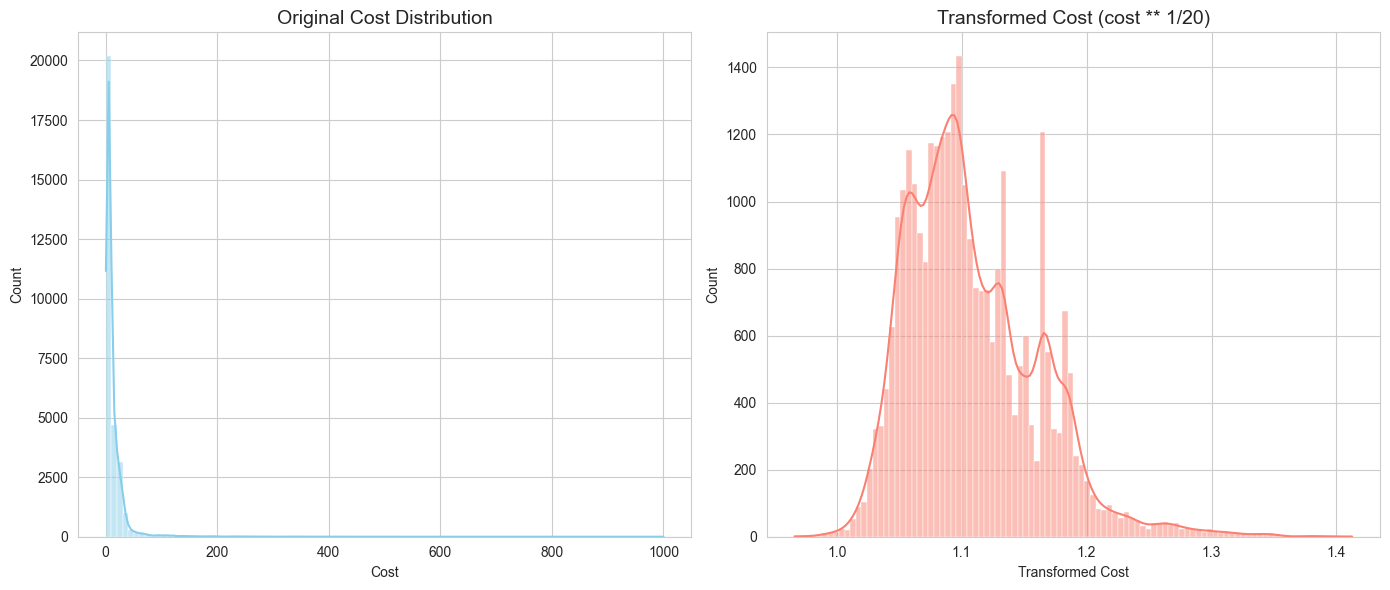

In [94]:
# Plot comparison
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(Final_DF['cost'], kde=True, bins=100, color='skyblue')
plt.title('Original Cost Distribution', fontsize=14)
plt.xlabel('Cost')

plt.subplot(1, 2, 2)
sns.histplot(Final_DF['cost_transformed'], kde=True, bins=100, color='salmon')
plt.title('Transformed Cost (cost ** 1/20)', fontsize=14)
plt.xlabel('Transformed Cost')

plt.tight_layout()
plt.show()

## Export Final Clean Data 

Finally the formal completion of our data engineering and preprocessing phase. Once all datasets are merged, columns cleaned, text identifiers converted to pure numbers, and redundant features removed, we must permanently lock our master table to disk.

Now we run our final file preservation command. We execute **Final_DF.to_csv('Final_DF.csv')** to overwrite our previous file draft and securely save the fully polished, feature-engineered, and cleaned master dataframe to a permanent CSV file on our disk workspace, marking the successful completion of our data preparation pipeline.

In [95]:
Final_DF.to_csv('Final_DF.csv')

# Data Visualisation

**Next, we calculate a correlation matrix exclusively for our numeric variables using Final_DF.select_dtypes.** 

To avoid visual clutter and make the chart easy for a viewer to interpret, we create a matching boolean matrix mask using np.zeros_like and fill its upper half with True using **np.triu_indices_from.** 

We apply **sns.set** to a clean white style, initialize a large **16 by 12 inch figure,** define a custom diverging palette that transitions smoothly between opposite color tones, and map our numeric correlations using **sns.heatmap** while applying our custom upper-triangle mask, clean line separations, and a centered baseline color bar.

<Axes: >

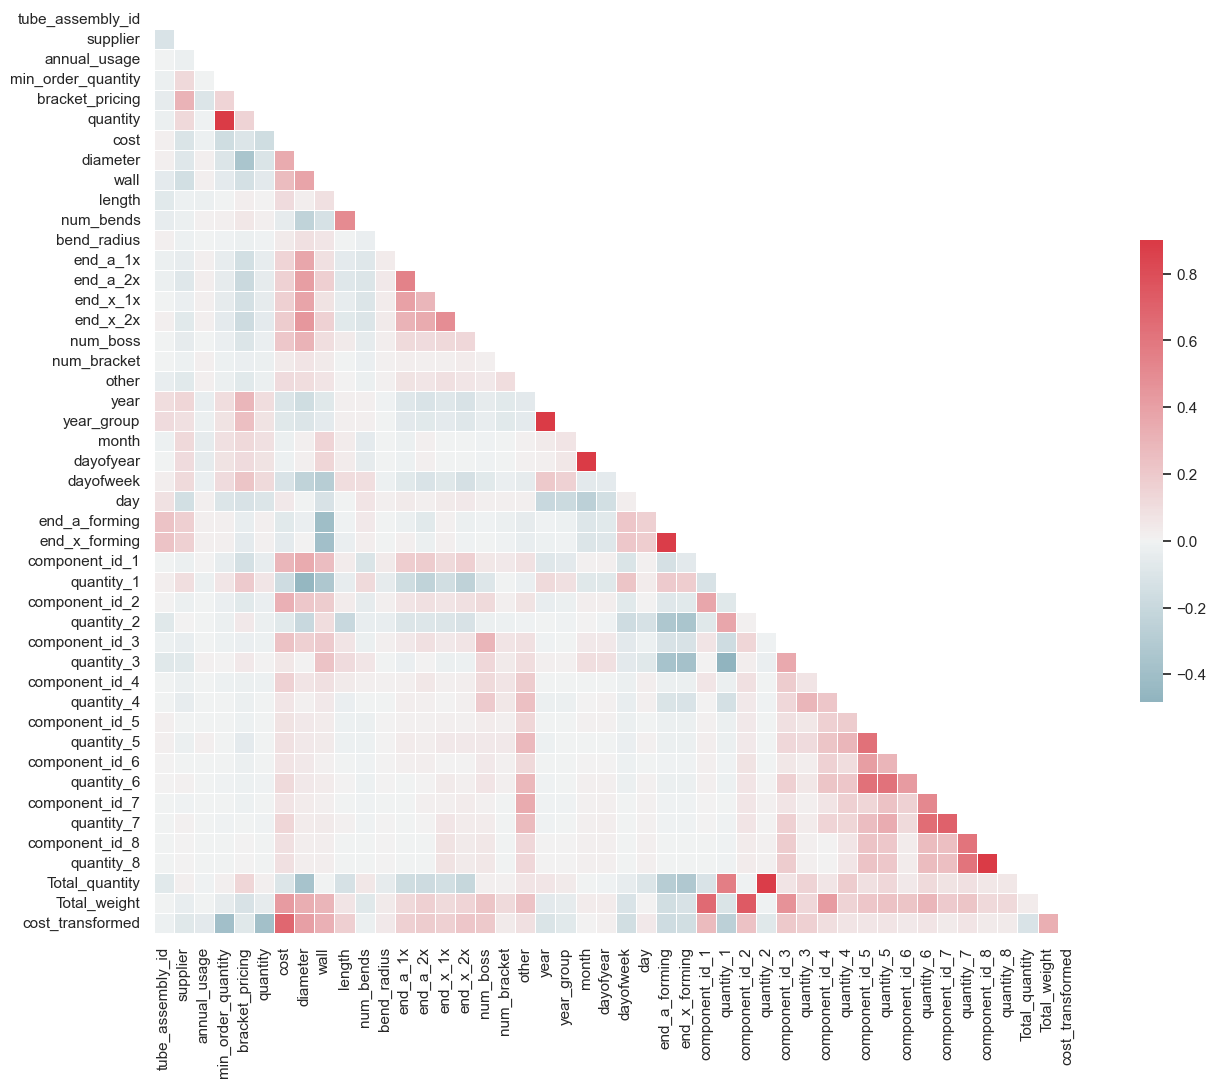

In [96]:
# Create correlation matrix (numeric only)
corr = Final_DF.select_dtypes(include=['number']).corr()

# Mask
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Plot
sns.set(style="white")
f, ax = plt.subplots(figsize=(16, 12))

cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmax=.9,
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .5}
)



Then, we cross-verify our independent feature interactions by generating an alternative full-grid correlation heatmap. 

We build a **14 by 10 inch canvas,** pass our numeric correlation matrix into a heatmap using a different color spectrum called **Red-Blue reversed** ('RdBu_r'), center our color scale midpoint at zero, and draw thin grid borders between cells. 

We add a clean title tracking features, establish tightly fitted padding boundaries, and display the chart to visually detect high multi-collinearity patterns where physical dimensions like weight, thickness, and length overlap.

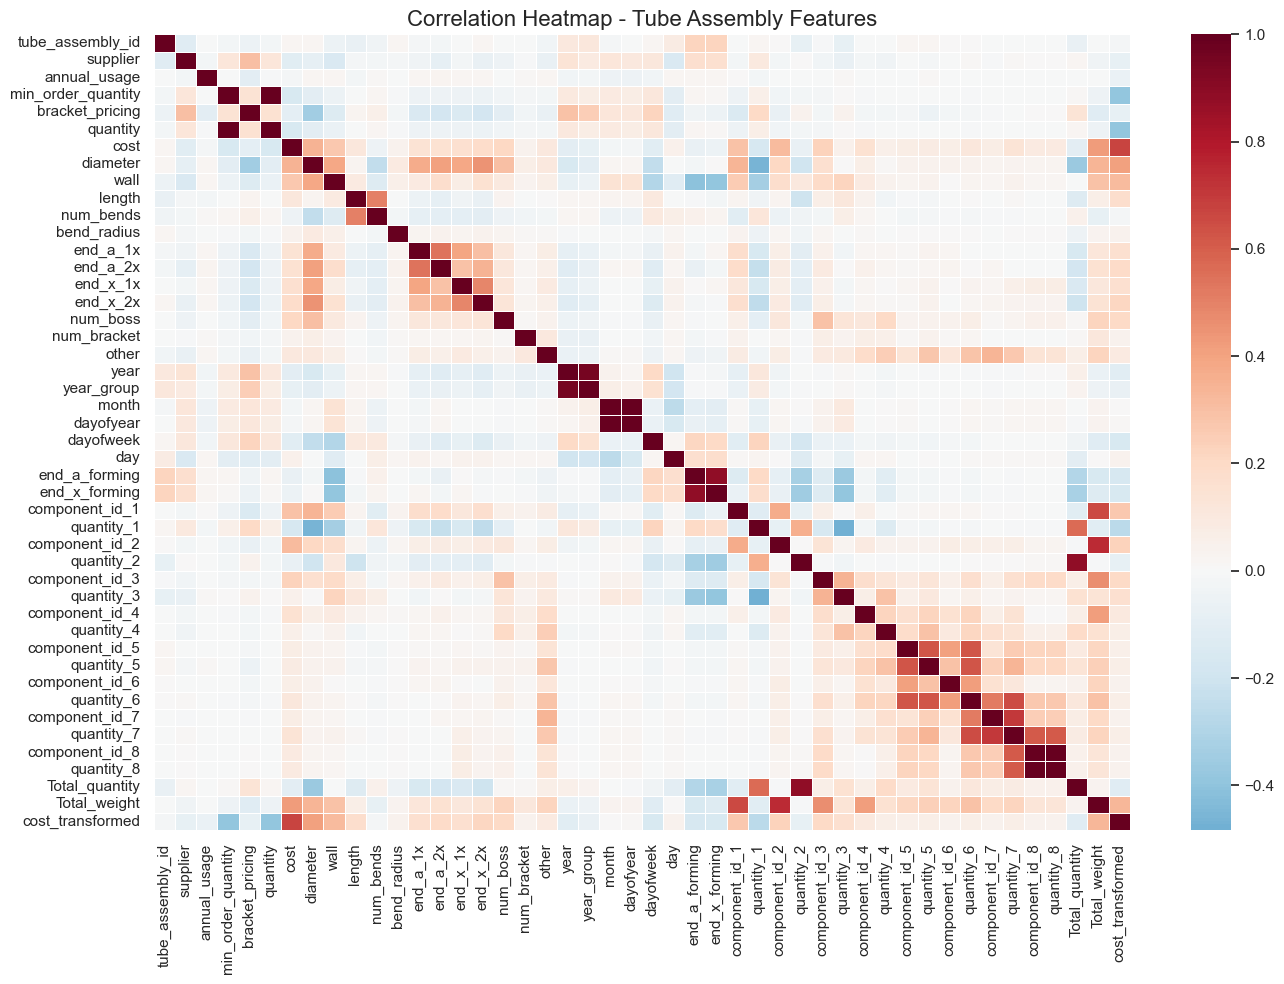

In [97]:
plt.figure(figsize=(14, 10))
sns.heatmap(Final_DF.select_dtypes(include='number').corr(), 
            annot=False, 
            cmap='RdBu_r', 
            center=0, 
            linewidths=0.5)
plt.title('Correlation Heatmap - Tube Assembly Features', fontsize=16)
plt.tight_layout()
plt.show()

After that, we evaluate how costs shift across different data partitions by building a box plot diagram. 

We initialize a **10 by 6 inch frame,** call **sns.boxplot** while binding our master dataframe, and assign our **categorical cluster divisions** along the horizontal x-axis while plotting our **numeric cost values** along the vertical y-axis. 

We add custom title text along with explicit labels for both axes and display the plot to visually evaluate the median price points, interquartile ranges, and extreme outlier thresholds across separate assembly subgroups.

cluster
3    14117
0    11303
2     4781
1       12
Name: count, dtype: int64


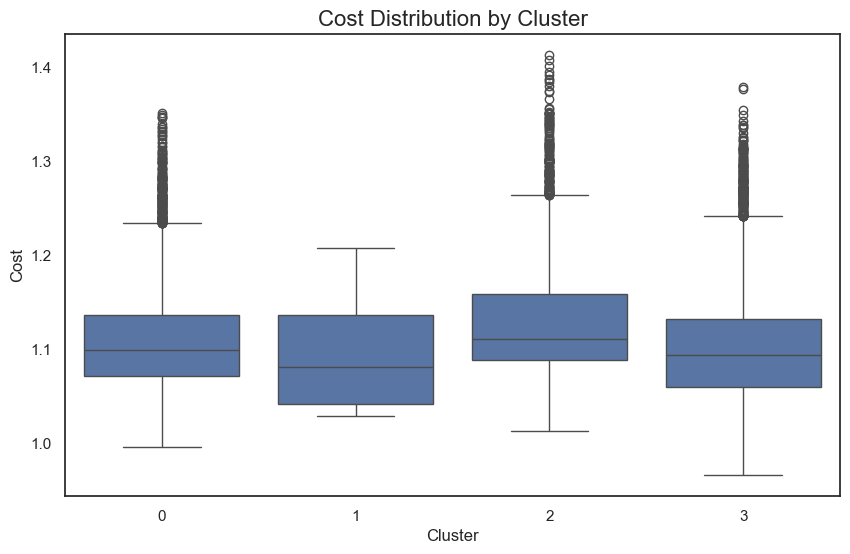

In [98]:
from sklearn.cluster import KMeans

# Select features for clustering
features = ['diameter', 'wall', 'length', 'num_bends', 'bend_radius', 
            'Total_weight', 'cost', 'num_boss', 'num_bracket']

X = Final_DF[features]

# Fit KMeans (example with 4 clusters)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
Final_DF['cluster'] = kmeans.fit_predict(X)

print(Final_DF['cluster'].value_counts())
plt.figure(figsize=(10, 6))
sns.boxplot(data=Final_DF, x='cluster', y='cost_transformed')
plt.title('Cost Distribution by Cluster', fontsize=16)
plt.xlabel('Cluster')
plt.ylabel('Cost')
plt.show()

Finally, we perform a deep multi-dimensional analysis by generating a grand master pair plot matrix. 

- We define a list named **key_cols** that isolates our most vital engineering and financial metrics: diameter, wall thickness, line length, bend counts, bend radius, cost, and our newly engineered total assembly weight variable. 

- We pass this specific slice to **sns.pairplot,** setting diag_kind to 'kde' to automatically draw smooth probability distributions along the central diagonal, and set corner to True to completely hide the mirror-image upper half of the chart grid. 

We add a prominent overarching matrix title, and call **plt.show()** to render a large array of interconnected scatter plots that visually maps out how our engineered physical parameters scale together with manufacturing costs.

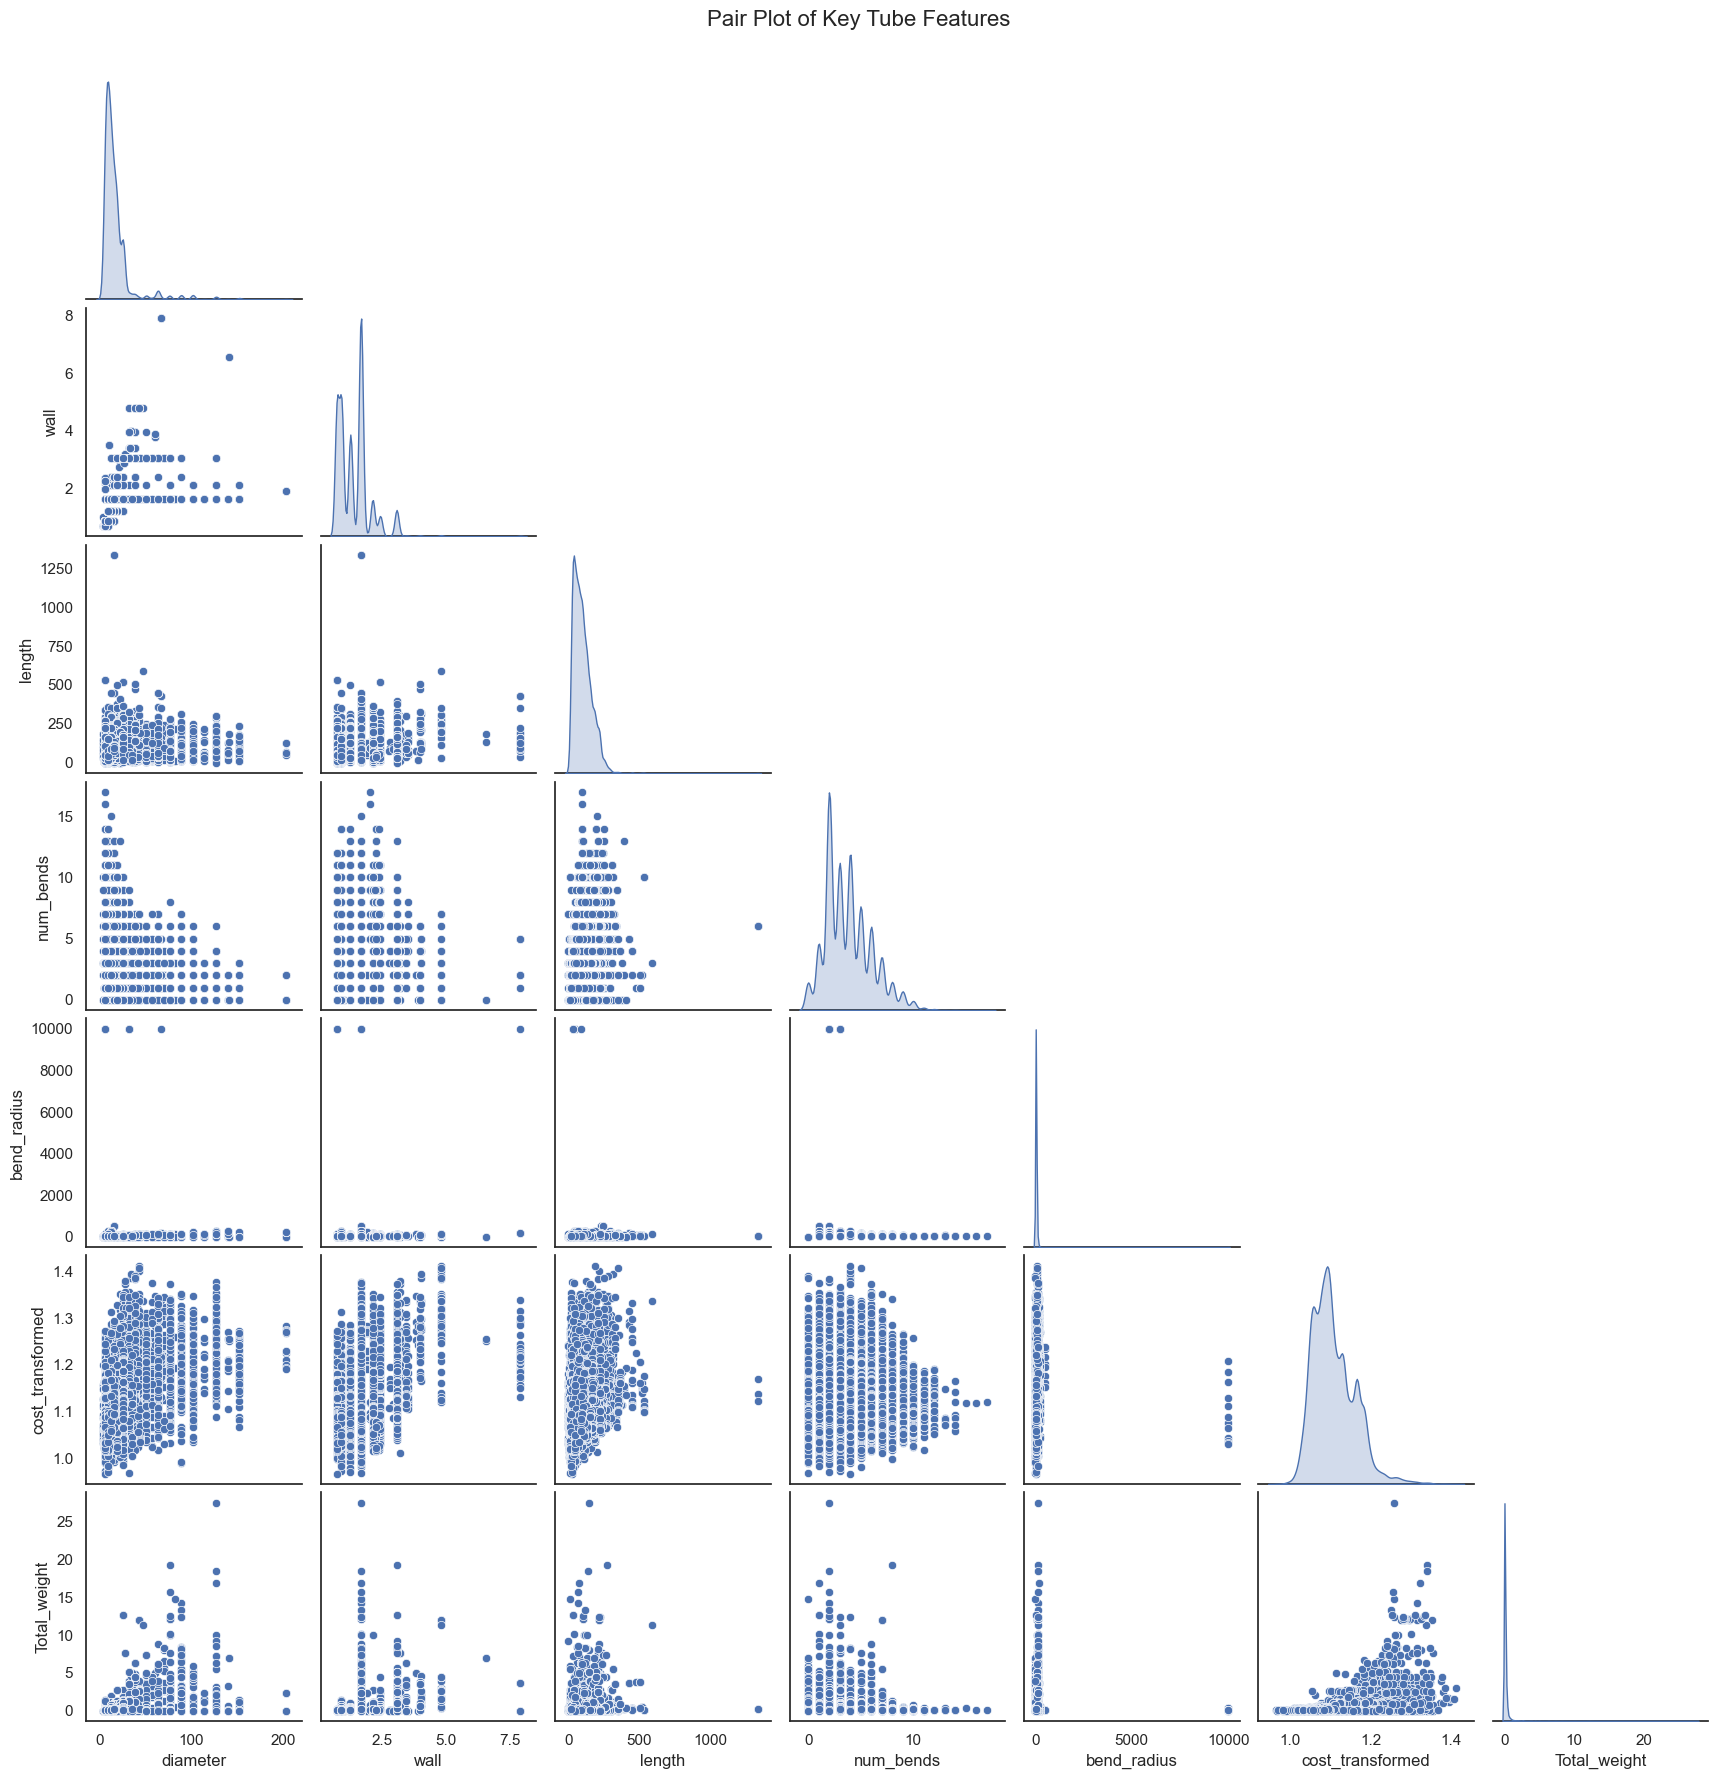

In [99]:
key_cols = ['diameter', 'wall', 'length', 'num_bends', 'bend_radius', 'cost_transformed', 'Total_weight']

sns.pairplot(Final_DF[key_cols], diag_kind='kde', corner=True)
plt.suptitle('Pair Plot of Key Tube Features', y=1.02, fontsize=16)
plt.show()